In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import optuna
from optuna.samplers import TPESampler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [3]:
data = pd.read_csv('application.csv')
data = data.sample(50000, random_state = 42)
data

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
245895,384575,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
98194,214010,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
36463,142232,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
249923,389171,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
158389,283617,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252818,392541,0,Cash loans,F,N,N,0,76500.0,450000.0,30442.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
185810,315401,0,Cash loans,M,N,N,0,90000.0,180000.0,14350.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
189290,319459,0,Revolving loans,M,Y,Y,0,405000.0,675000.0,33750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
39297,145509,0,Cash loans,F,Y,Y,1,135000.0,521280.0,31630.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,7.0


In [4]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,50000.0,NaN,NaN,NaN,277922.7923,102627.575389,100002.0,189456.5,278094.0,366733.75,456247.0
TARGET,50000.0,NaN,NaN,NaN,0.08046,0.272007,0.0,0.0,0.0,0.0,1.0
NAME_CONTRACT_TYPE,50000,2,Cash loans,45356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,50000,3,F,33049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,50000,2,N,33131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,43204.0,NaN,NaN,NaN,0.008425,0.132539,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_WEEK,43204.0,NaN,NaN,NaN,0.03546,0.207138,0.0,0.0,0.0,0.0,6.0
AMT_REQ_CREDIT_BUREAU_MON,43204.0,NaN,NaN,NaN,0.269628,0.928304,0.0,0.0,0.0,0.0,22.0
AMT_REQ_CREDIT_BUREAU_QRT,43204.0,NaN,NaN,NaN,0.26067,0.609136,0.0,0.0,0.0,0.0,7.0


In [5]:
missing_data = pd.DataFrame({'Total Missing': data.isnull().sum(),
                             'Percentage': (data.isnull().sum()/len(data))*100})
missing_data = missing_data[missing_data['Total Missing'] > 0].sort_values(by='Percentage', ascending=False)

print("Columns with missing values and their percentages:")
display(missing_data)


print("\nData types of columns with missing values:")
display(data[missing_data.index].dtypes)

Columns with missing values and their percentages:


,Total Missing,Percentage
COMMONAREA_MODE,34890,69.780
COMMONAREA_AVG,34890,69.780
COMMONAREA_MEDI,34890,69.780
NONLIVINGAPARTMENTS_MEDI,34631,69.262
NONLIVINGAPARTMENTS_MODE,34631,69.262
...,...,...
OBS_30_CNT_SOCIAL_CIRCLE,166,0.332
EXT_SOURCE_2,103,0.206
AMT_GOODS_PRICE,45,0.090
AMT_ANNUITY,2,0.004



Data types of columns with missing values:


,0
COMMONAREA_MODE,float64
COMMONAREA_AVG,float64
COMMONAREA_MEDI,float64
NONLIVINGAPARTMENTS_MEDI,float64
NONLIVINGAPARTMENTS_MODE,float64
...,...
OBS_30_CNT_SOCIAL_CIRCLE,float64
EXT_SOURCE_2,float64
AMT_GOODS_PRICE,float64
AMT_ANNUITY,float64


### Handling Missing Values

Based on the analysis, we will proceed with the following strategy:
1.  **Drop columns** where more than 60% of the values are missing.
2.  For the remaining numerical columns with missing values, **impute them with the median**.

In [6]:
# Drop columns with more than 60% missing values
missing_threshold = 60
columns_to_drop = missing_data[missing_data['Percentage'] > missing_threshold].index.tolist()

print(f"Dropping {len(columns_to_drop)} columns with more than {missing_threshold}% missing values:")
print(columns_to_drop)

data = data.drop(columns=columns_to_drop)
print(f"Shape of data after dropping columns: {data.shape}")

Dropping 17 columns with more than 60% missing values:
['COMMONAREA_MODE', 'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE']
Shape of data after dropping columns: (50000, 105)


In [7]:
for i in data.columns:
    if pd.api.types.is_numeric_dtype(data[i]):
        data[i] = data[i].fillna(value=data[i].mean())
    else:
        data[i] = data[i].fillna(value=data[i].mode()[0])

data.isnull().sum().sum()

np.int64(0)

In [8]:
# 1. Income per person
data['INCOME_PER_PERSON'] = data['AMT_INCOME_TOTAL'] / data['CNT_FAM_MEMBERS']

# 2. Annuity to Income Ratio
data['ANNUITY_INCOME_RATIO'] = data['AMT_ANNUITY'] / data['AMT_INCOME_TOTAL']

# 3. Credit to Income Ratio
data['CREDIT_TO_INCOME_RATIO'] = data['AMT_CREDIT'] / data['AMT_INCOME_TOTAL']

# 4. Credit to Annuity Ratio
data['CREDIT_TO_ANNUITY_RATIO'] = data['AMT_CREDIT'] / data['AMT_ANNUITY']

# 5. Product of External Sources (captures combined external information)
data['EXT_SOURCES_PROD'] = data['EXT_SOURCE_1'] * data['EXT_SOURCE_2'] * data['EXT_SOURCE_3']

# 6. Mean of External Sources (average external score)
data['EXT_SOURCES_MEAN'] = (data['EXT_SOURCE_1'] + data['EXT_SOURCE_2'] + data['EXT_SOURCE_3']) / 3

# 7. Percentage of life employed (DAYS_EMPLOYED is negative, DAYS_BIRTH is negative)
data['DAYS_EMPLOYED_PERCENT'] = data['DAYS_EMPLOYED'] / data['DAYS_BIRTH']

# 8. Percentage of life since last phone change
data['DAYS_LAST_PHONE_CHANGE_PERCENT'] = data['DAYS_LAST_PHONE_CHANGE'] / data['DAYS_BIRTH']

# 9. Total number of recent credit bureau inquiries
data['BUR_AMT_REQ_SUM'] = data['AMT_REQ_CREDIT_BUREAU_HOUR'] + \
                                   data['AMT_REQ_CREDIT_BUREAU_DAY'] + \
                                   data['AMT_REQ_CREDIT_BUREAU_WEEK'] + \
                                   data['AMT_REQ_CREDIT_BUREAU_MON'] + \
                                   data['AMT_REQ_CREDIT_BUREAU_QRT'] + \
                                   data['AMT_REQ_CREDIT_BUREAU_YEAR']

# 10. Difference between Credit and Goods Price (margin or additional loan amount)
data['AMT_DIFF_CREDIT_GOODS'] = data['AMT_CREDIT'] - data['AMT_GOODS_PRICE']

print(f"Successfully created 10 new features. Current shape of data: {data.shape}")

# Display the first few rows with new features to verify
display(data[['SK_ID_CURR', 'INCOME_PER_PERSON', 'ANNUITY_INCOME_RATIO', 'CREDIT_TO_INCOME_RATIO', 'CREDIT_TO_ANNUITY_RATIO',
                       'EXT_SOURCES_PROD', 'EXT_SOURCES_MEAN', 'DAYS_EMPLOYED_PERCENT', 'DAYS_LAST_PHONE_CHANGE_PERCENT',
                       'BUR_AMT_REQ_SUM', 'AMT_DIFF_CREDIT_GOODS']].head())

Successfully created 10 new features. Current shape of data: (50000, 115)


/tmp/ipykernel_7751/1308088882.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['INCOME_PER_PERSON'] = data['AMT_INCOME_TOTAL'] / data['CNT_FAM_MEMBERS']
/tmp/ipykernel_7751/1308088882.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['ANNUITY_INCOME_RATIO'] = data['AMT_ANNUITY'] / data['AMT_INCOME_TOTAL']
/tmp/ipykernel_7751/1308088882.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all column

,SK_ID_CURR,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_TO_INCOME_RATIO,CREDIT_TO_ANNUITY_RATIO,EXT_SOURCES_PROD,EXT_SOURCES_MEAN,DAYS_EMPLOYED_PERCENT,DAYS_LAST_PHONE_CHANGE_PERCENT,BUR_AMT_REQ_SUM,AMT_DIFF_CREDIT_GOODS
245895,384575,51750.0,0.254304,2.248587,8.842110,0.000216,0.427100,0.057306,0.000150,2.0,46957.5
98194,214010,247500.0,0.197764,5.178636,26.185989,0.130504,0.522778,0.077209,0.072473,4.0,102712.5
36463,142232,101250.0,0.193133,2.444444,12.656771,0.058306,0.422321,0.035684,0.080136,4.0,0.0
249923,389171,247500.0,0.100764,1.029091,10.212920,0.213925,0.603326,0.355753,0.101906,0.0,29700.0
158389,283617,112500.0,0.141000,2.738960,19.425248,0.233668,0.617316,0.054361,0.008511,4.0,74133.0


In [9]:
def handle_high_cardinality(df, threshold=10):
    df = df.copy()
    cat_cols = df.select_dtypes(include=['object']).columns

    for col in cat_cols:
        num_unique = df[col].nunique()
        if num_unique > threshold:
            print(f'Processing {col}: {num_unique} unique values')
            # Keep top 'threshold' categories, group rest as 'Other'
            top_categories = df[col].value_counts().nlargest(threshold).index
            df[col] = df[col].apply(lambda x: x if x in top_categories else 'Other')
            print(f'--> Reduced {col} to {df[col].nunique()} values.')
        else:
            print(f'Skipping {col}: only {num_unique} unique values')
    return df

# 1. Drop ID column
if 'SK_ID_CURR' in data.columns:
    data.drop(columns=['SK_ID_CURR'], inplace=True)

# 2. Drop any column where unique values > 90% of total rows (likely IDs or noise)
rows = len(data)
for col in data.columns:
    if data[col].nunique() > (rows * 0.9):
        print(f'Dropping {col} due to extreme cardinality (ID-like).')
        data.drop(columns=[col], inplace=True)

# 3. Apply the generalized grouping for categorical columns
data = handle_high_cardinality(data, threshold=50)

print(f'\nFinal data shape: {data.shape}')
display(data)

Dropping EXT_SOURCES_PROD due to extreme cardinality (ID-like).
Dropping EXT_SOURCES_MEAN due to extreme cardinality (ID-like).
Dropping DAYS_EMPLOYED_PERCENT due to extreme cardinality (ID-like).
Skipping NAME_CONTRACT_TYPE: only 2 unique values
Skipping CODE_GENDER: only 3 unique values
Skipping FLAG_OWN_CAR: only 2 unique values
Skipping FLAG_OWN_REALTY: only 2 unique values
Skipping NAME_TYPE_SUITE: only 7 unique values
Skipping NAME_INCOME_TYPE: only 8 unique values
Skipping NAME_EDUCATION_TYPE: only 5 unique values
Skipping NAME_FAMILY_STATUS: only 6 unique values
Skipping NAME_HOUSING_TYPE: only 6 unique values
Skipping OCCUPATION_TYPE: only 18 unique values
Skipping WEEKDAY_APPR_PROCESS_START: only 7 unique values
Processing ORGANIZATION_TYPE: 58 unique values
--> Reduced ORGANIZATION_TYPE to 50 values.
Skipping HOUSETYPE_MODE: only 3 unique values
Skipping WALLSMATERIAL_MODE: only 7 unique values
Skipping EMERGENCYSTATE_MODE: only 2 unique values

Final data shape: (50000, 111

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_TO_INCOME_RATIO,CREDIT_TO_ANNUITY_RATIO,DAYS_LAST_PHONE_CHANGE_PERCENT,BUR_AMT_REQ_SUM,AMT_DIFF_CREDIT_GOODS
245895,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,418500.0,...,1.000000,0.00000,1.000000,51750.0,0.254304,2.248587,8.842110,0.000150,2.000000,46957.5
98194,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,1179000.0,...,1.000000,0.00000,3.000000,247500.0,0.197764,5.178636,26.185989,0.072473,4.000000,102712.5
36463,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,495000.0,...,1.000000,0.00000,3.000000,101250.0,0.193133,2.444444,12.656771,0.080136,4.000000,0.0
249923,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,225000.0,...,0.000000,0.00000,0.000000,247500.0,0.100764,1.029091,10.212920,0.101906,0.000000,29700.0
158389,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,234000.0,...,0.000000,0.00000,4.000000,112500.0,0.141000,2.738960,19.425248,0.008511,4.000000,74133.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252818,0,Cash loans,F,N,N,0,76500.0,450000.0,30442.5,450000.0,...,0.269628,0.26067,1.896723,38250.0,0.397941,5.882353,14.781966,0.067986,2.477363,0.0
185810,0,Cash loans,M,N,N,0,90000.0,180000.0,14350.5,180000.0,...,0.269628,0.26067,1.896723,90000.0,0.159450,2.000000,12.543117,0.063783,2.477363,0.0
189290,0,Revolving loans,M,Y,Y,0,405000.0,675000.0,33750.0,675000.0,...,0.000000,0.00000,2.000000,202500.0,0.083333,1.666667,20.000000,0.012575,2.000000,0.0
39297,0,Cash loans,F,Y,Y,1,135000.0,521280.0,31630.5,450000.0,...,0.000000,1.00000,7.000000,45000.0,0.234300,3.861333,16.480296,0.154802,8.000000,71280.0


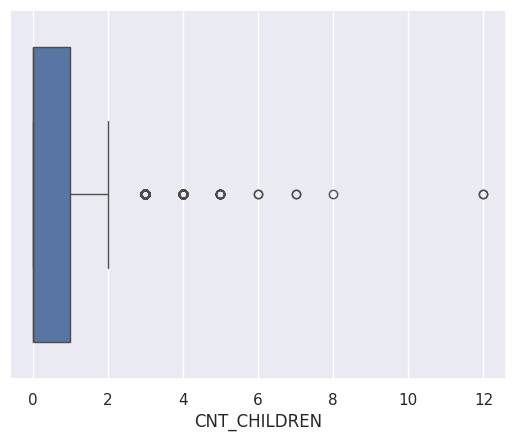

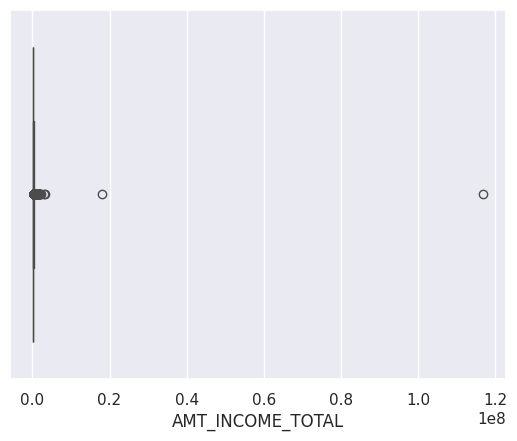

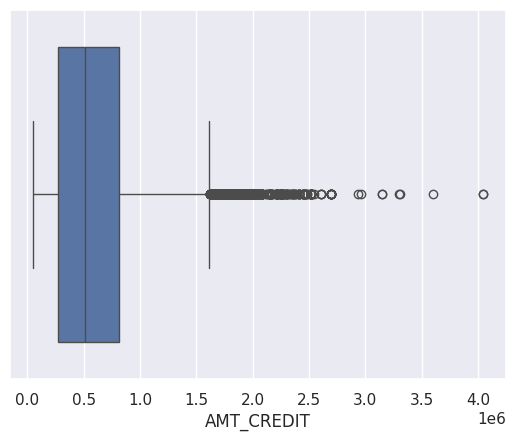

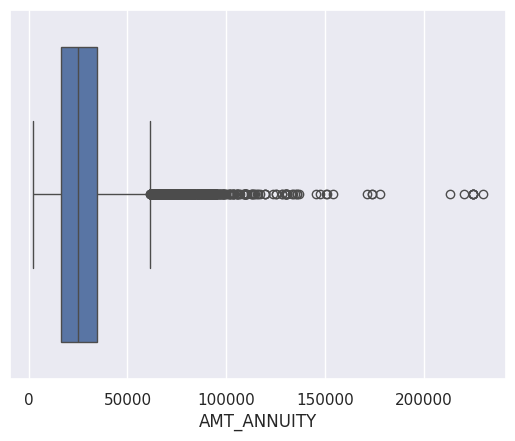

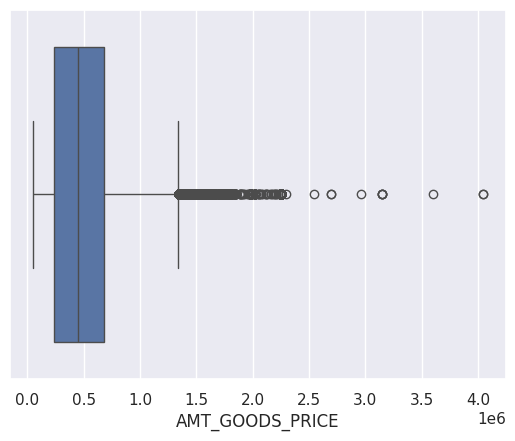

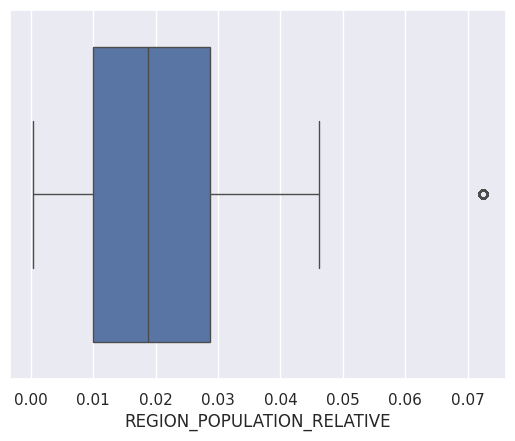

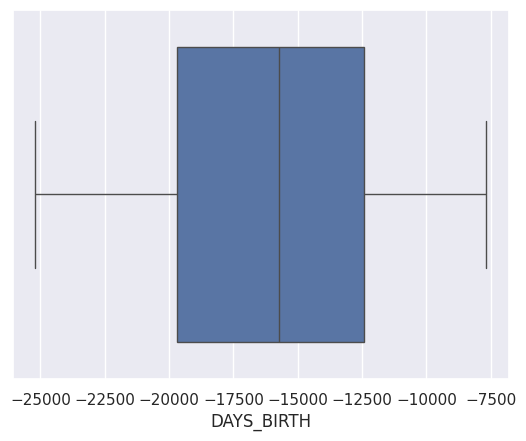

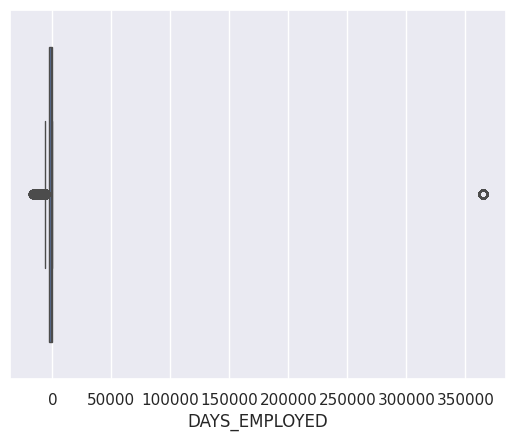

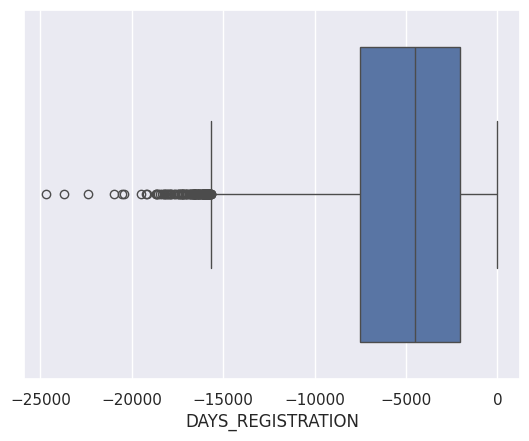

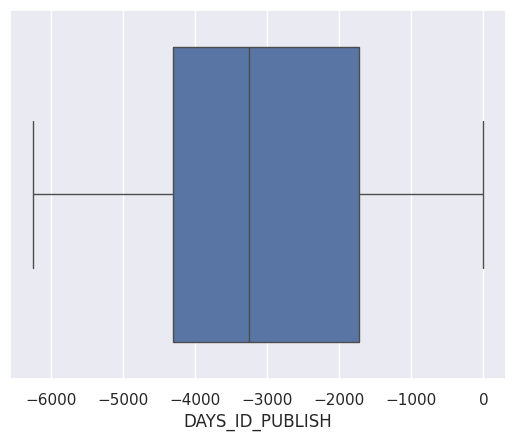

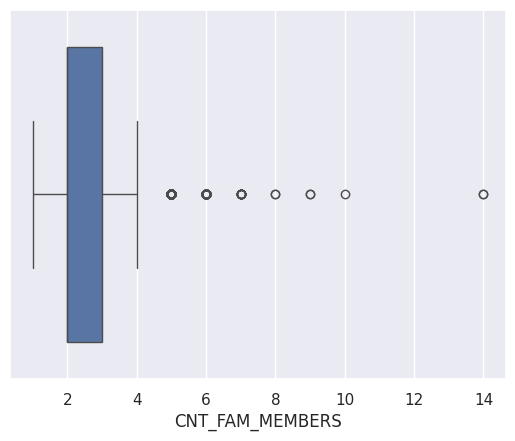

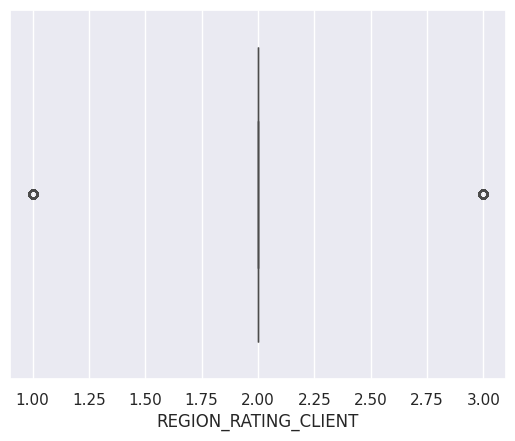

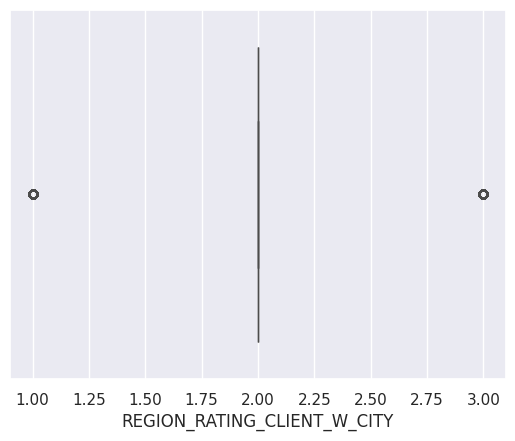

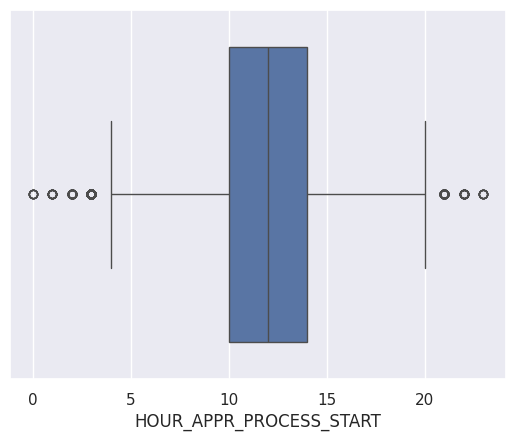

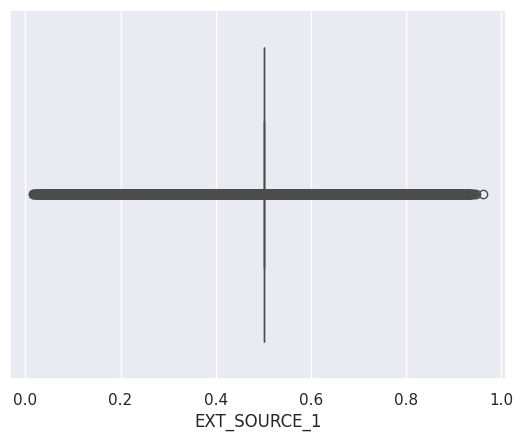

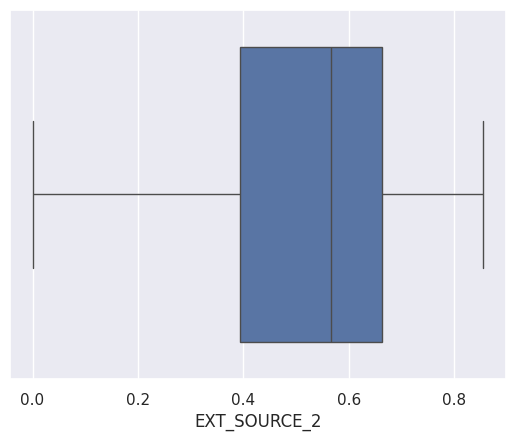

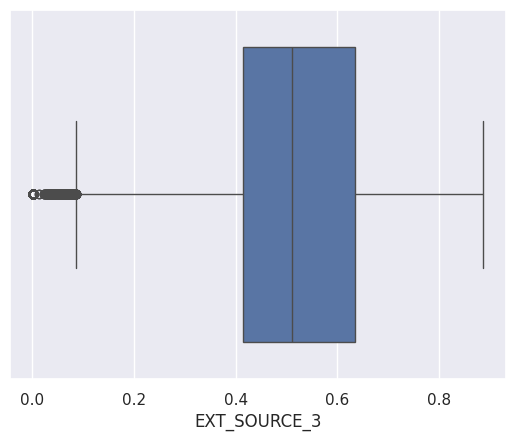

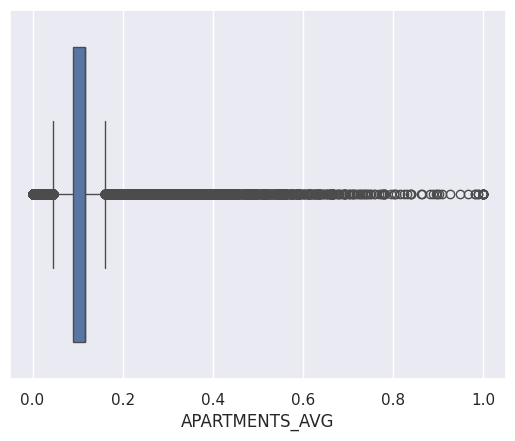

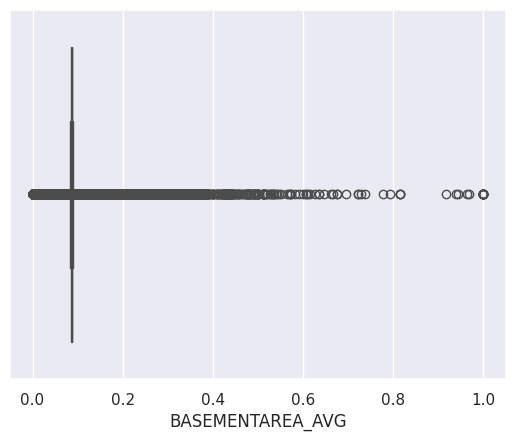

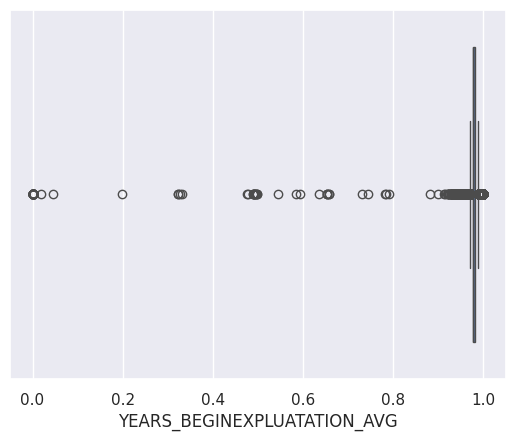

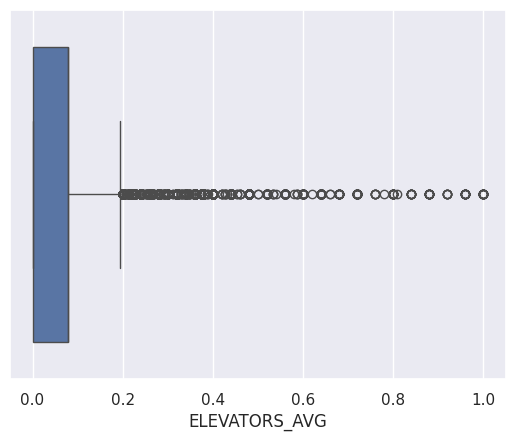

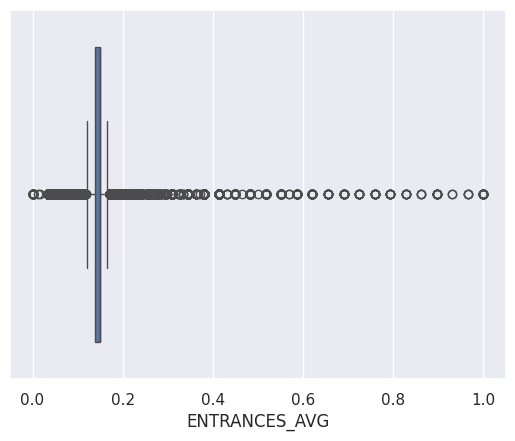

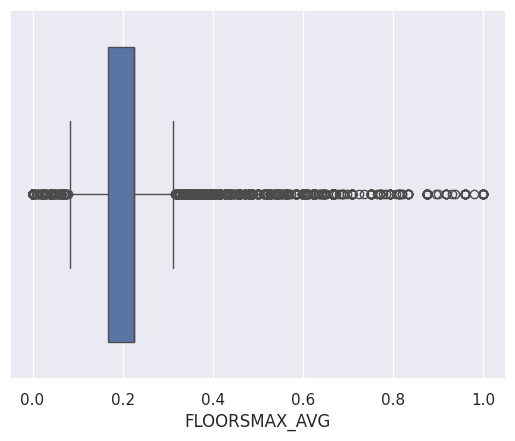

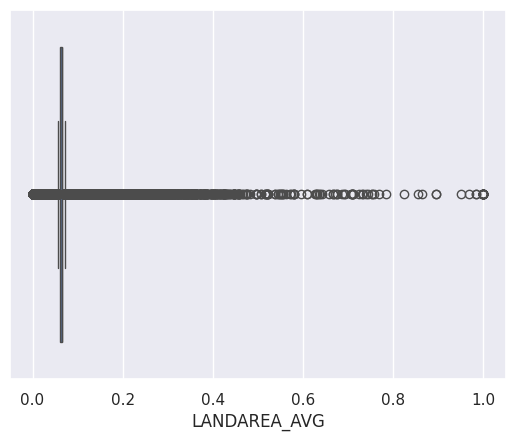

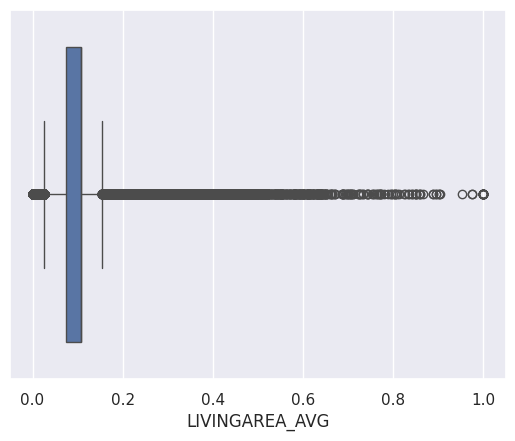

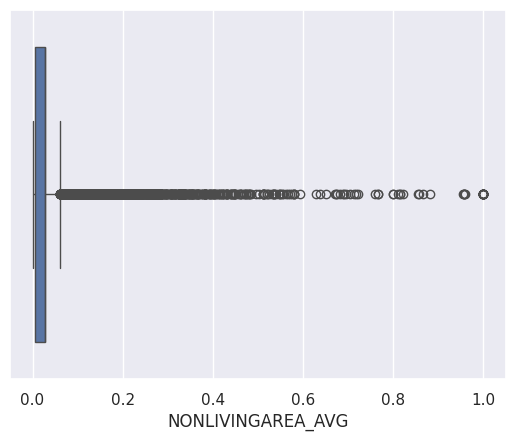

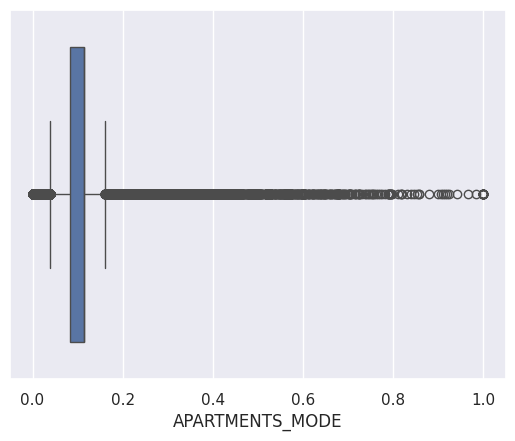

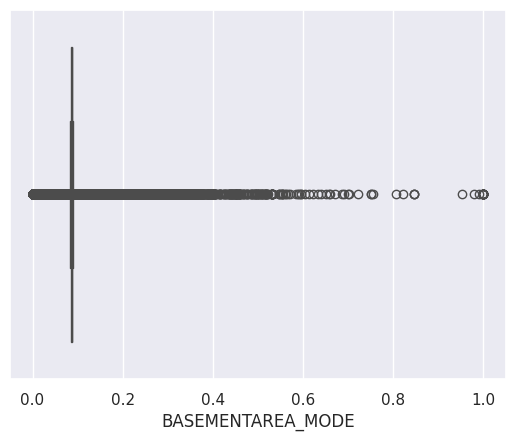

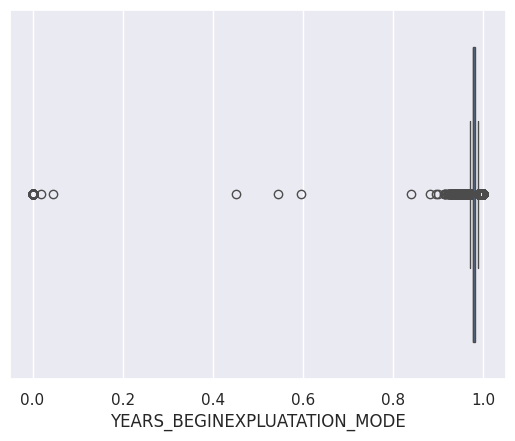

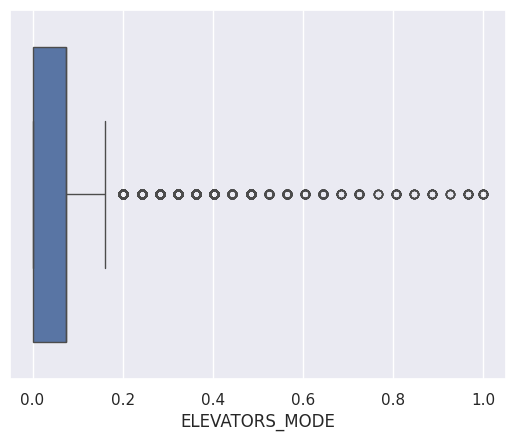

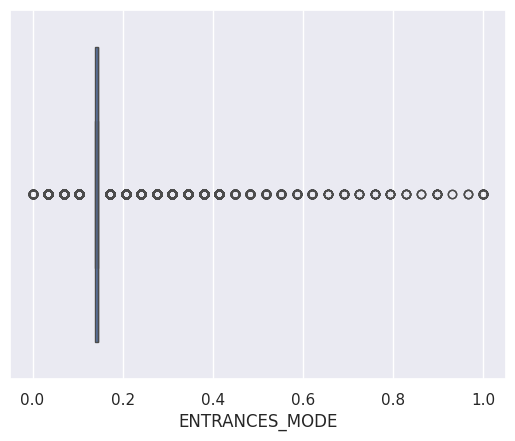

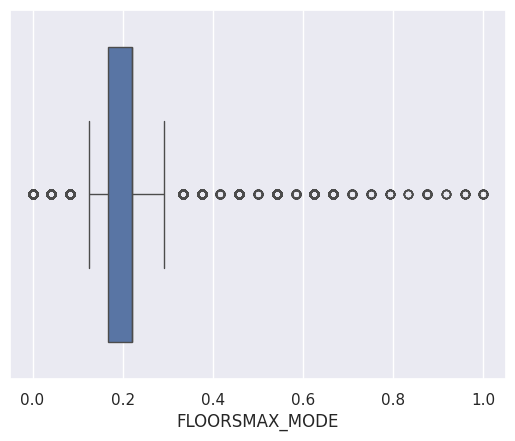

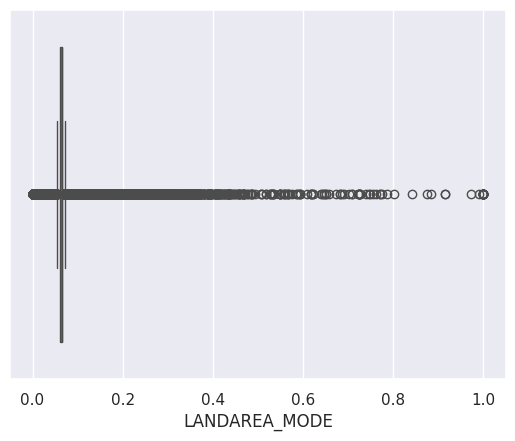

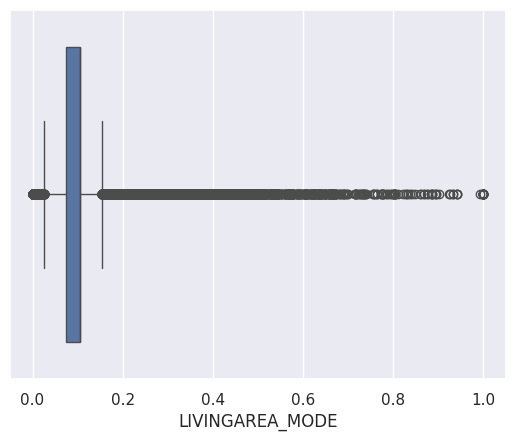

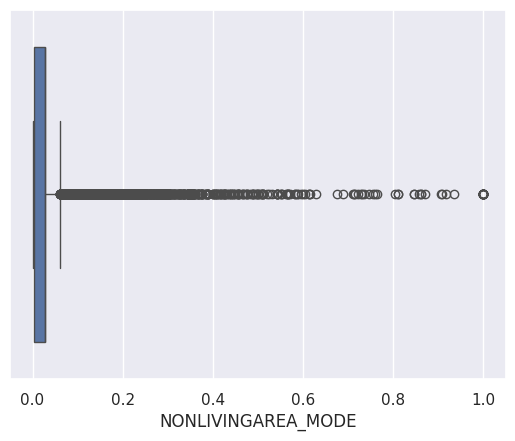

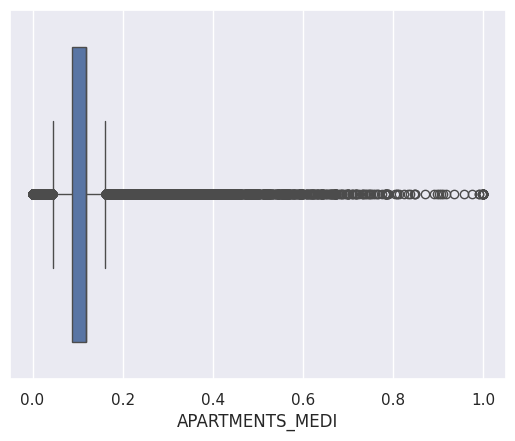

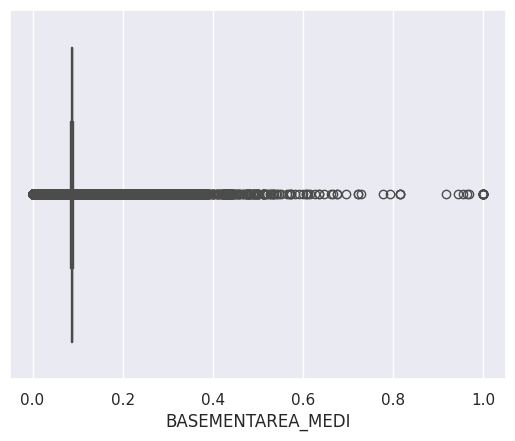

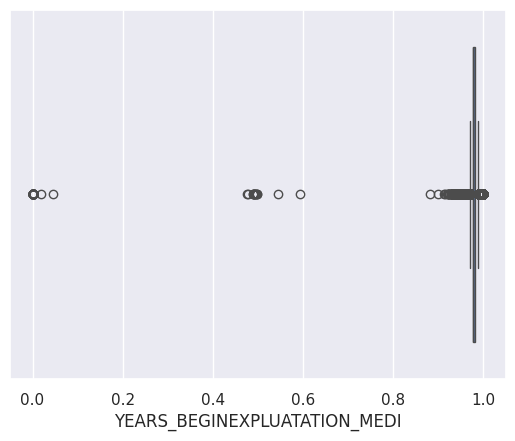

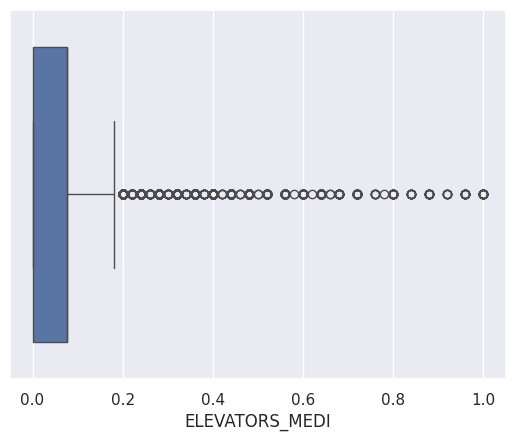

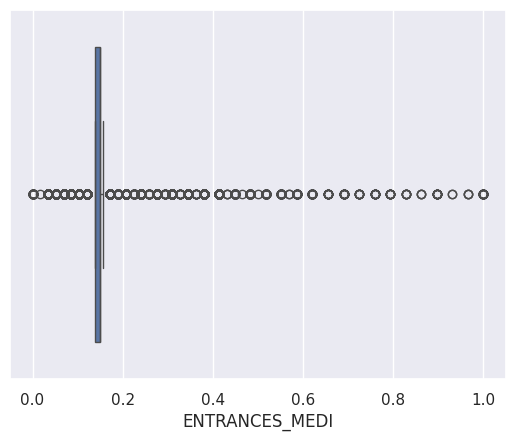

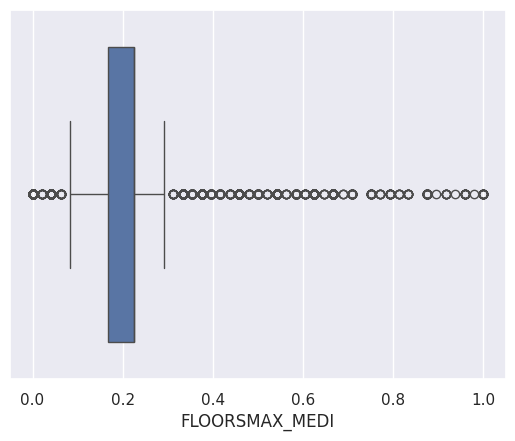

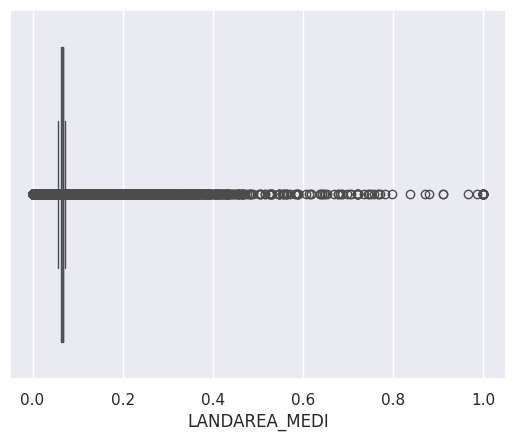

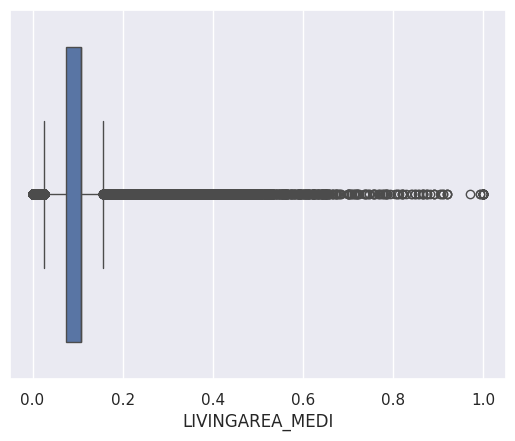

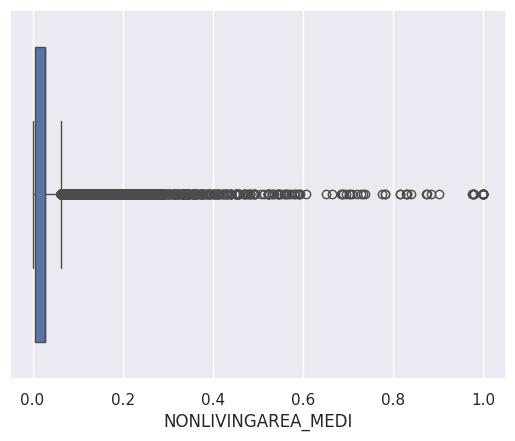

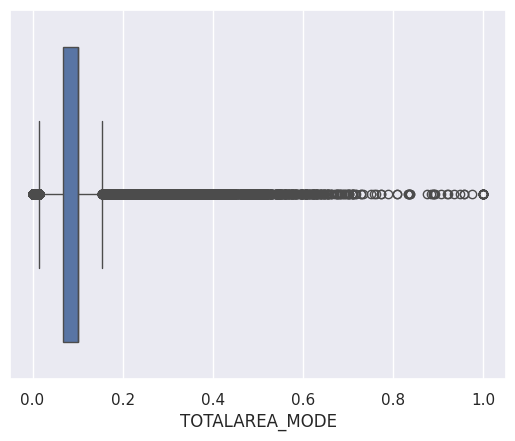

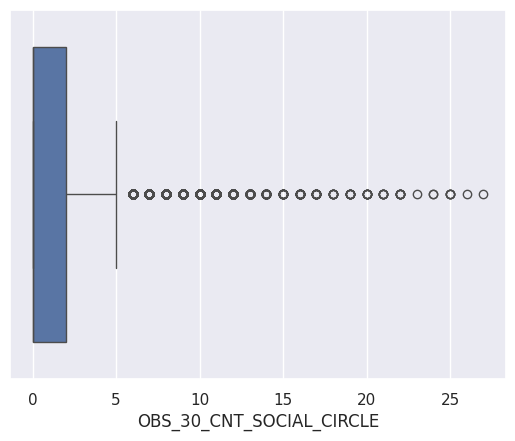

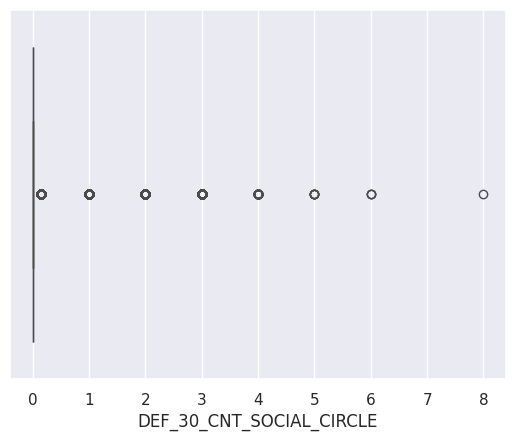

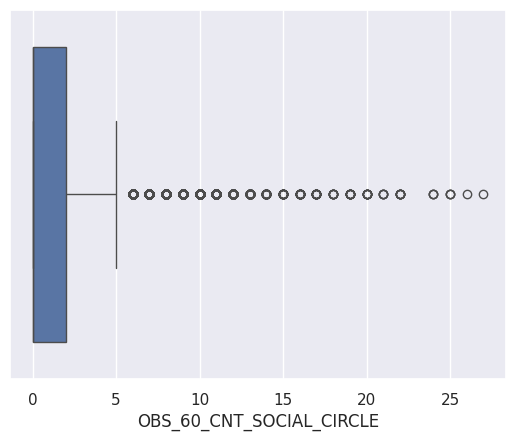

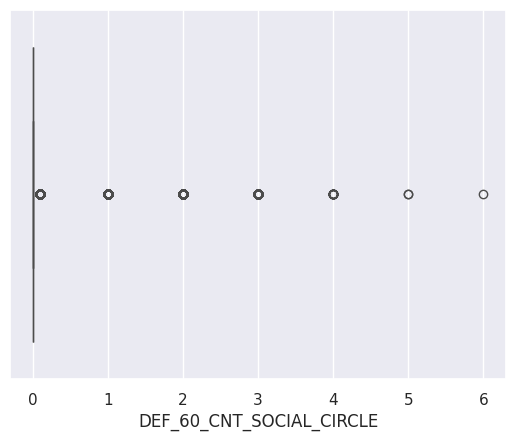

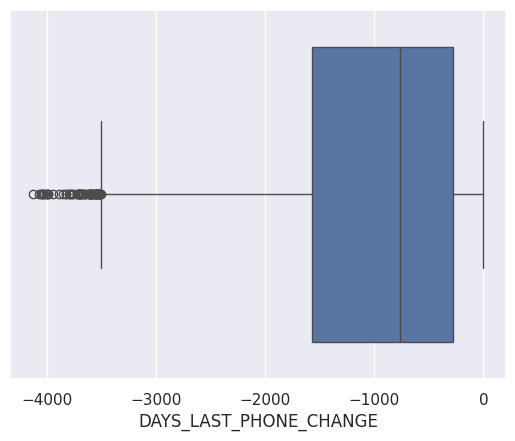

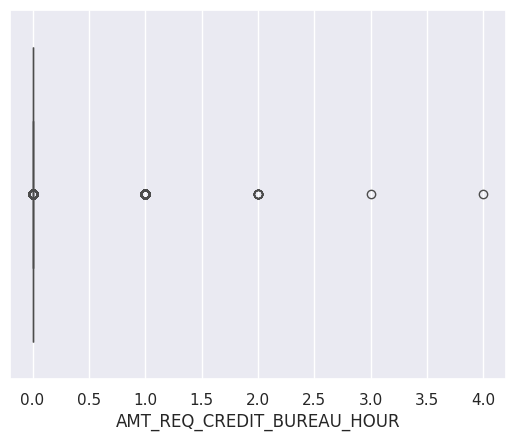

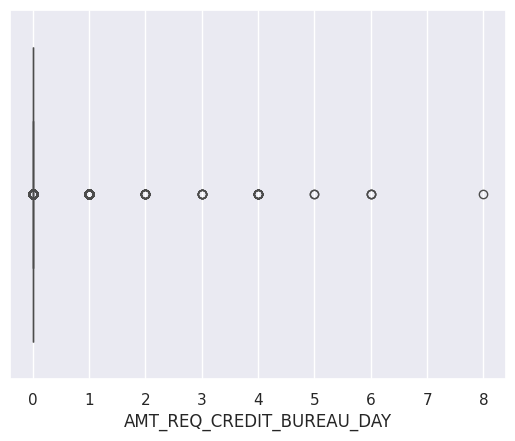

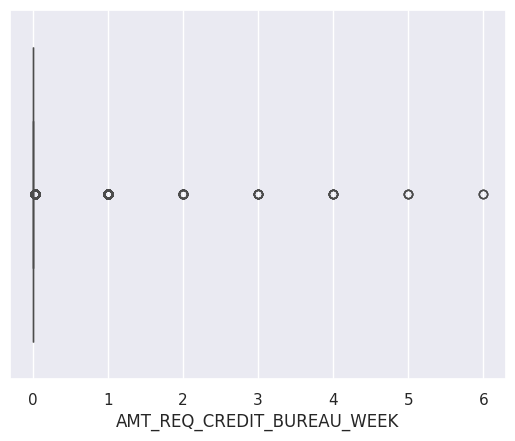

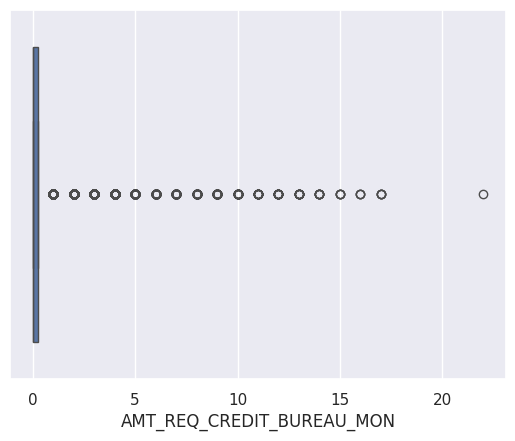

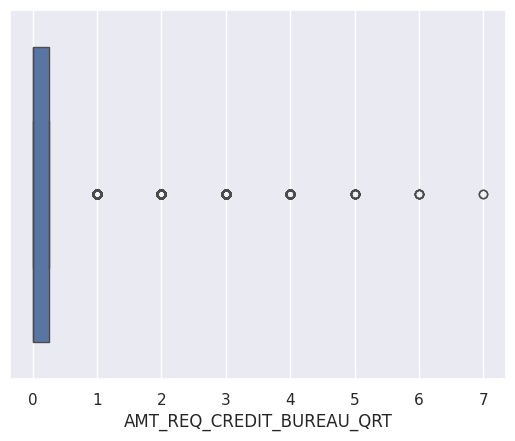

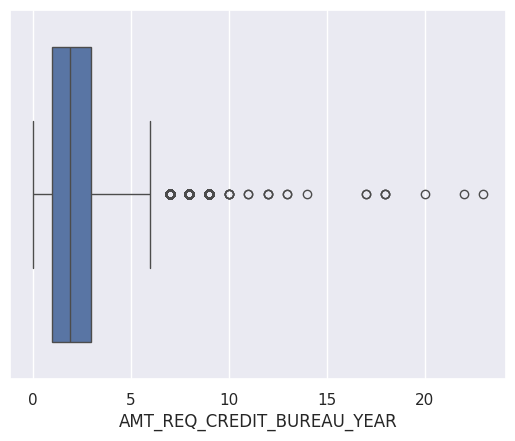

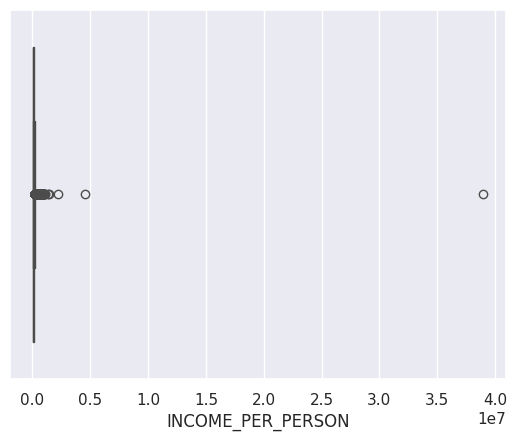

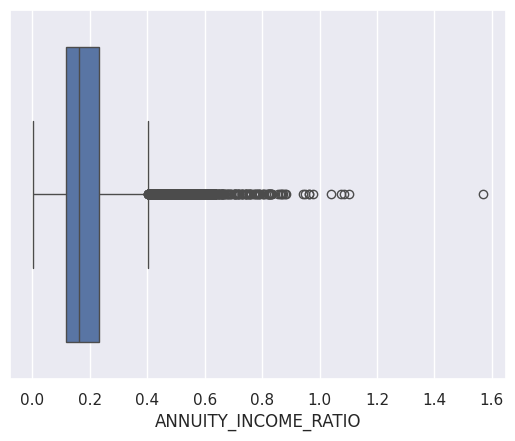

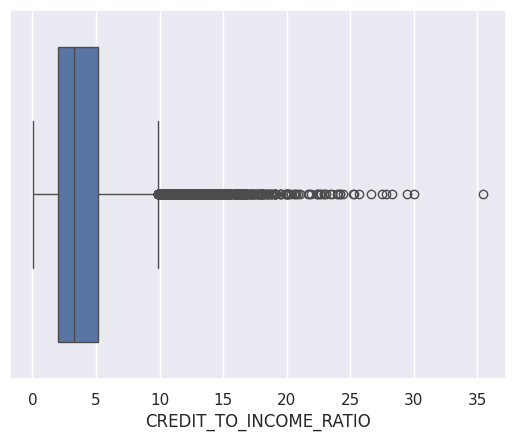

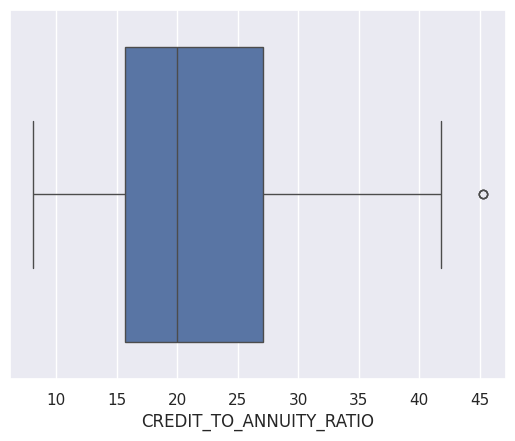

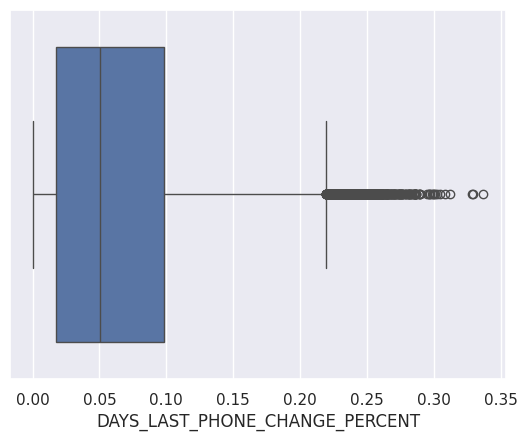

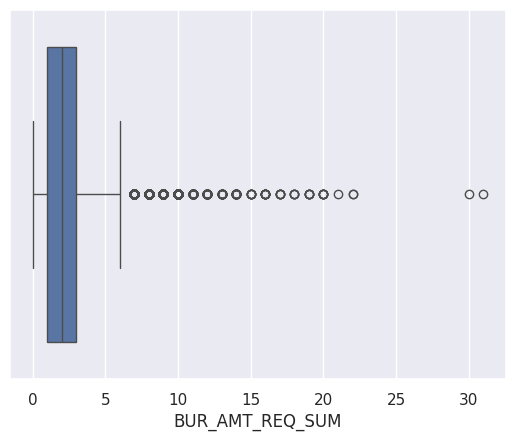

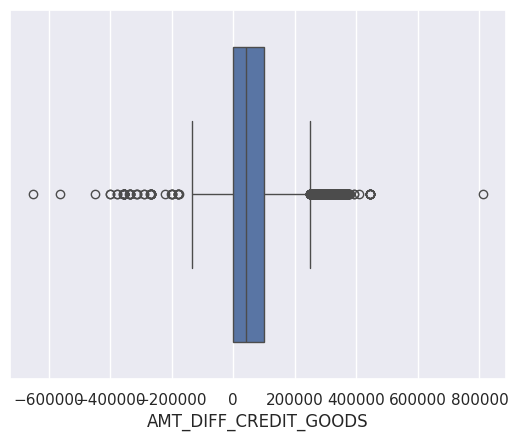

In [10]:
for i in data.columns:
    if data[i].dtype !=object and data[i].nunique() > 2 and i != 'TARGET':
        sns.boxplot(data=data,x=data[i])
        plt.show()

In [11]:
q1=data.quantile(0.25, numeric_only=True)
q3=data.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

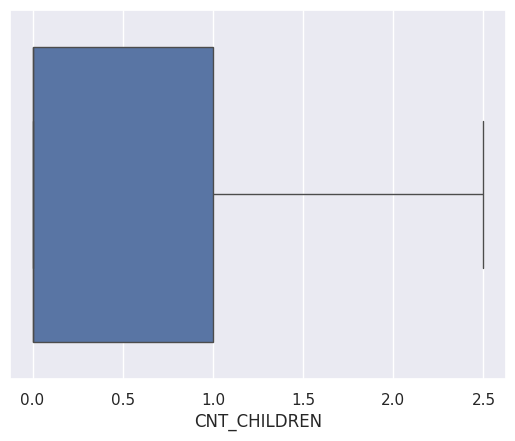

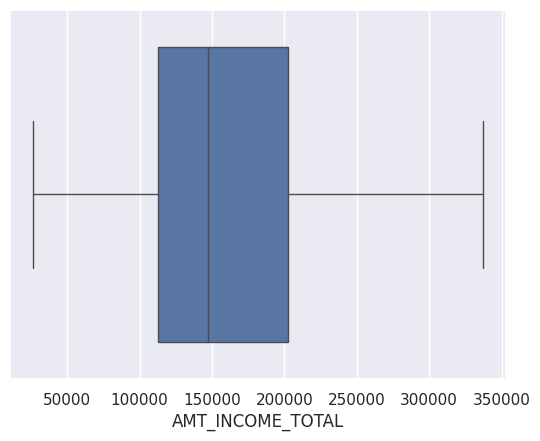

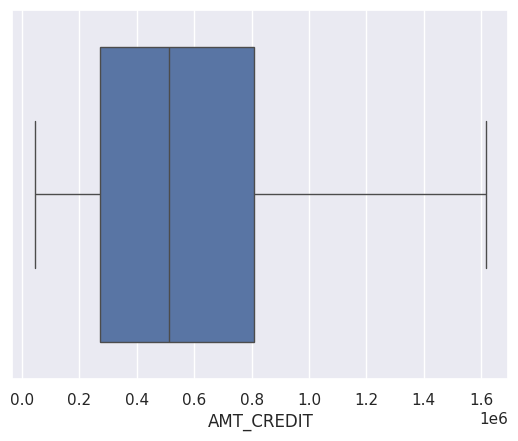

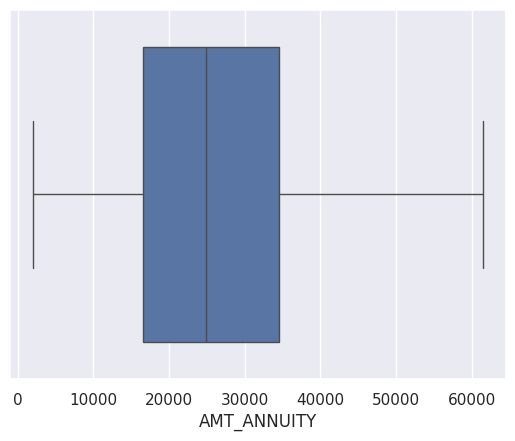

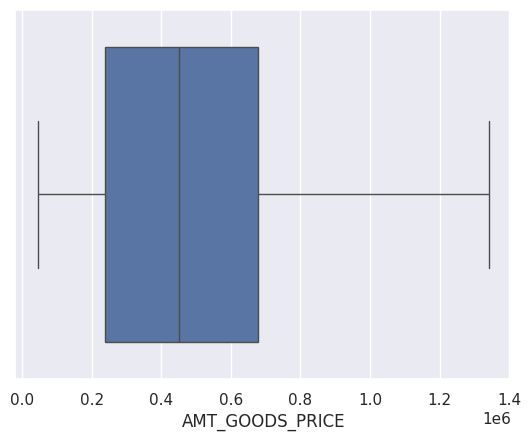

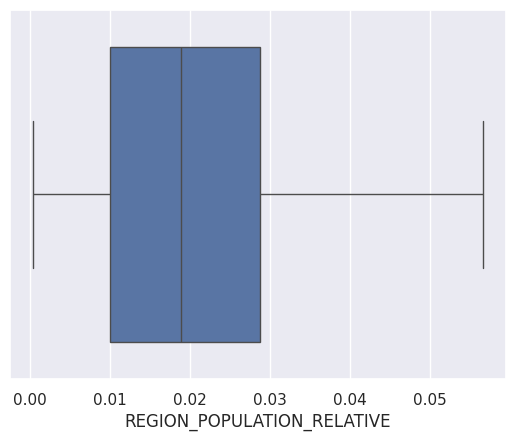

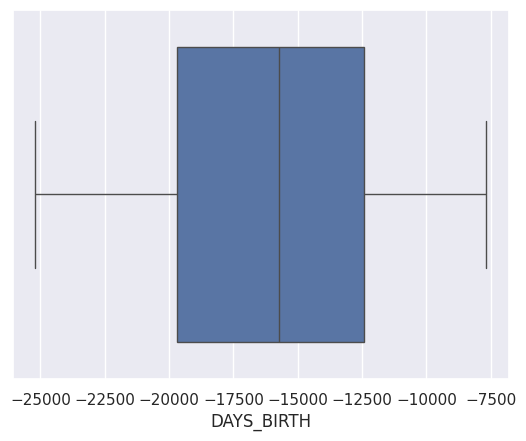

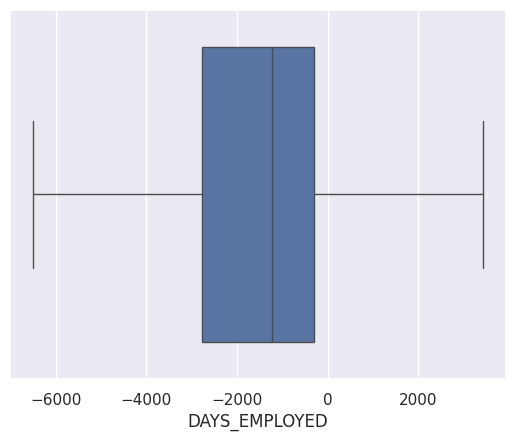

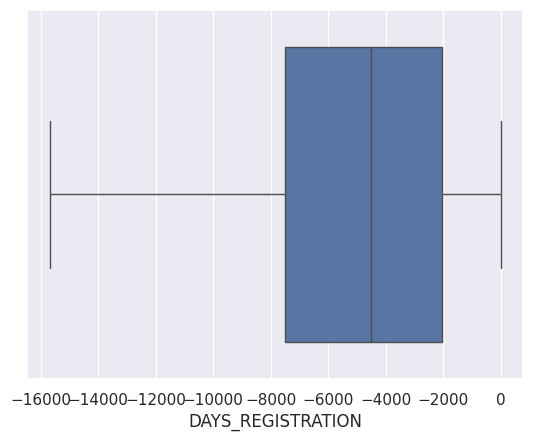

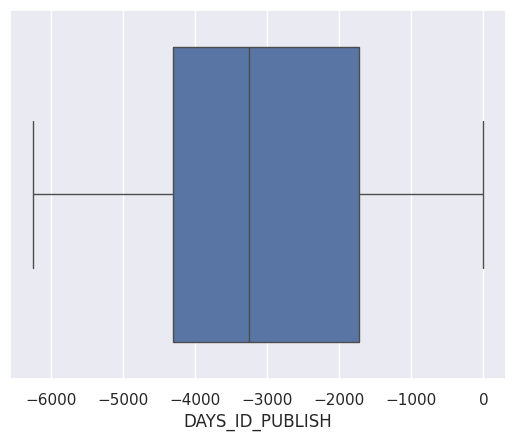

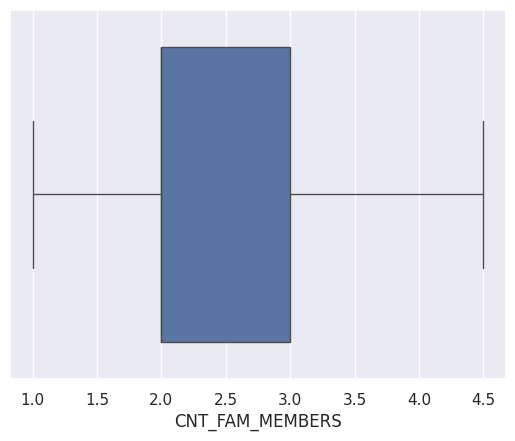

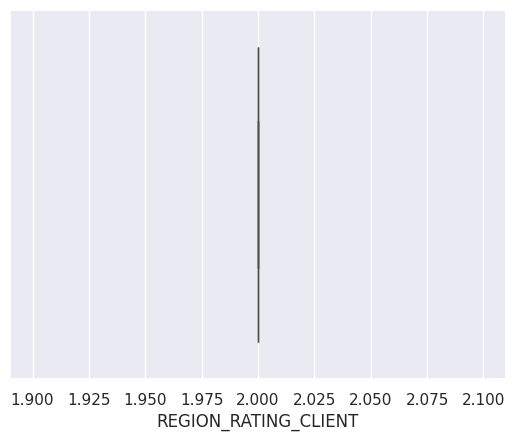

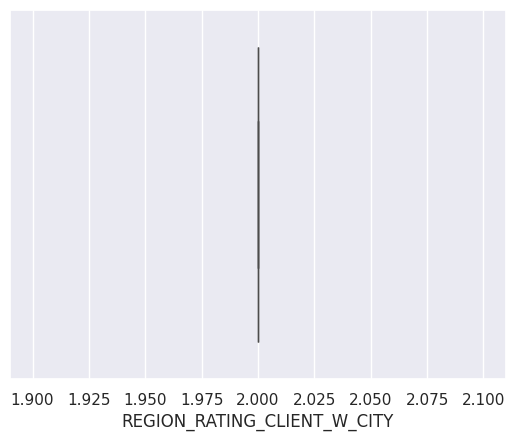

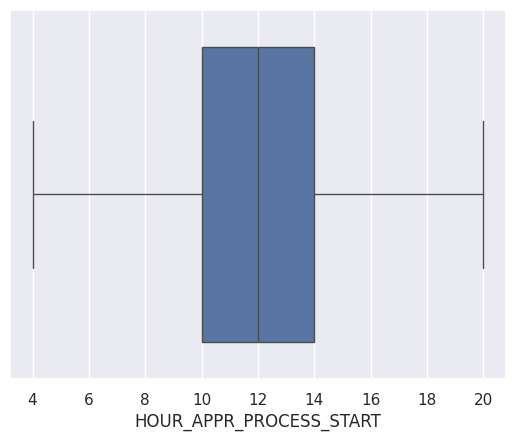

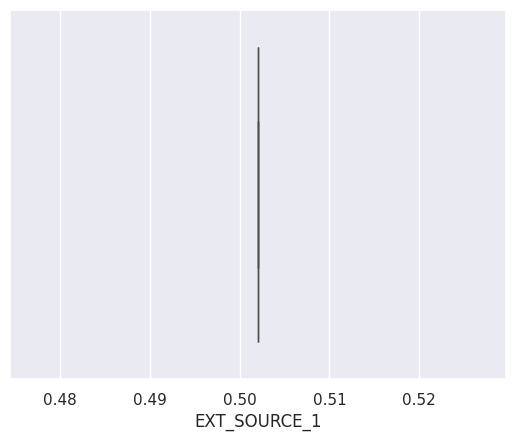

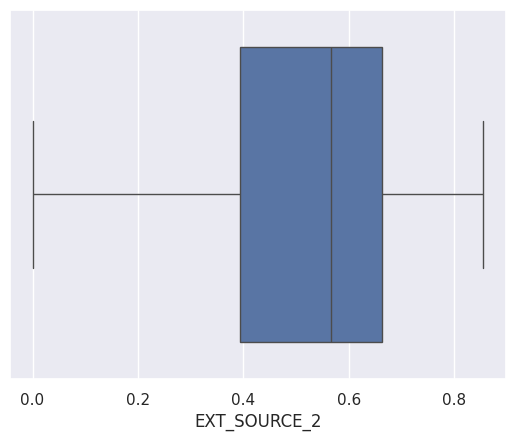

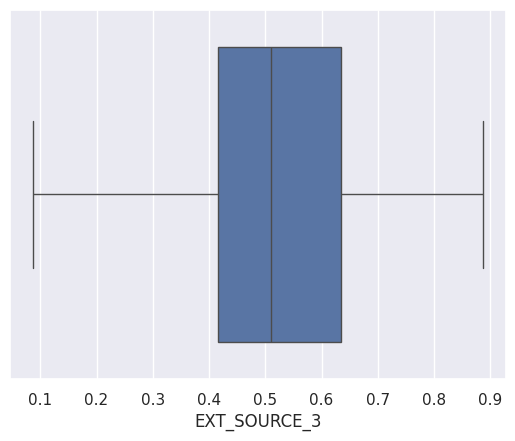

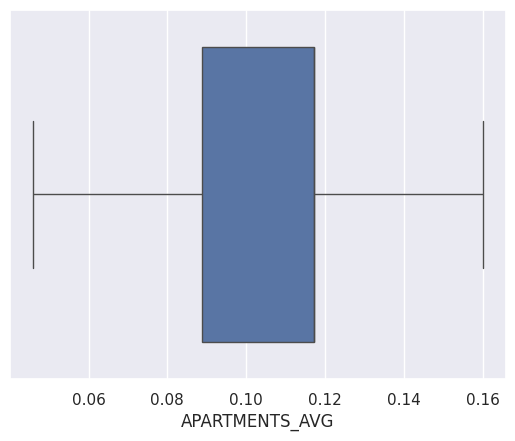

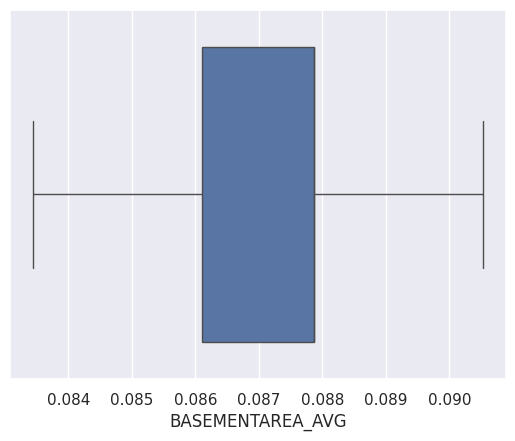

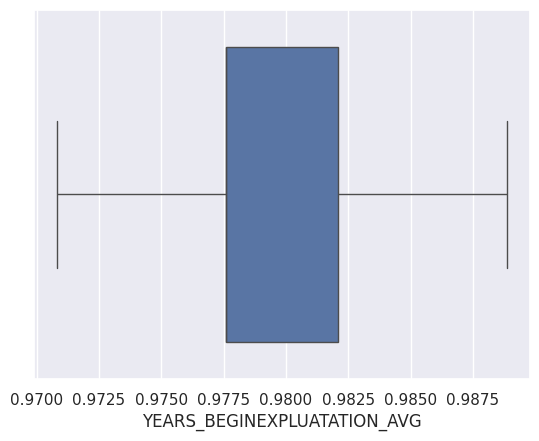

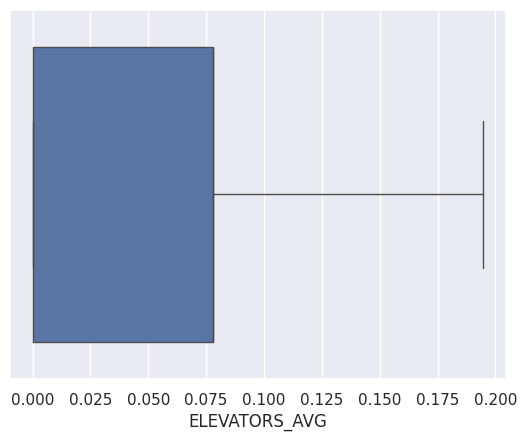

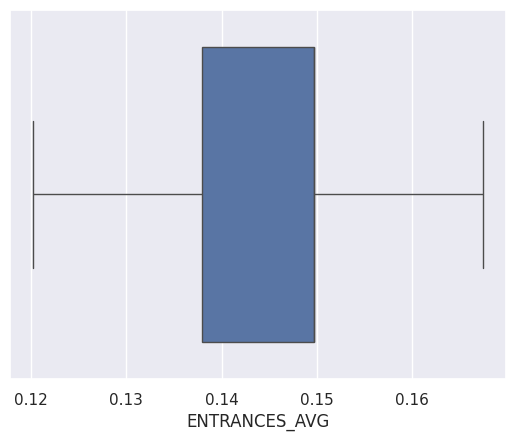

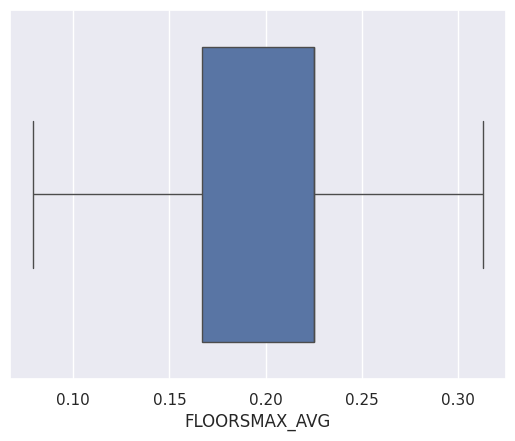

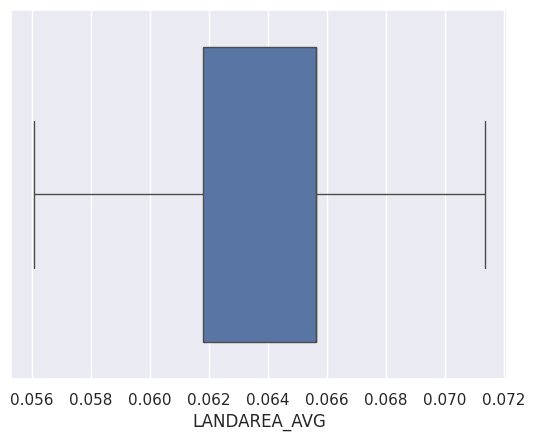

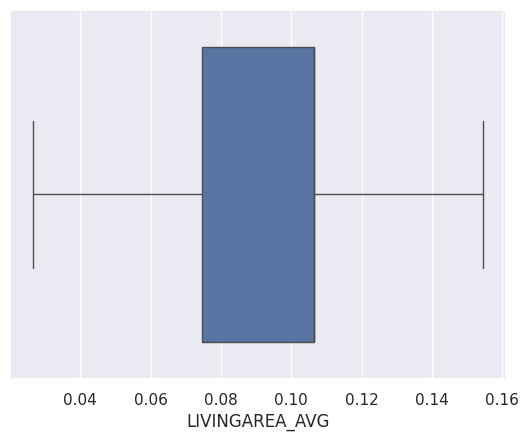

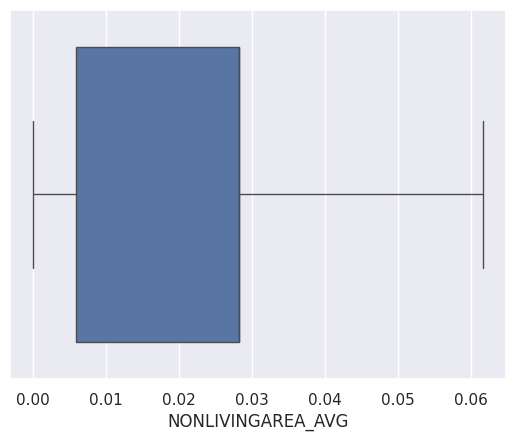

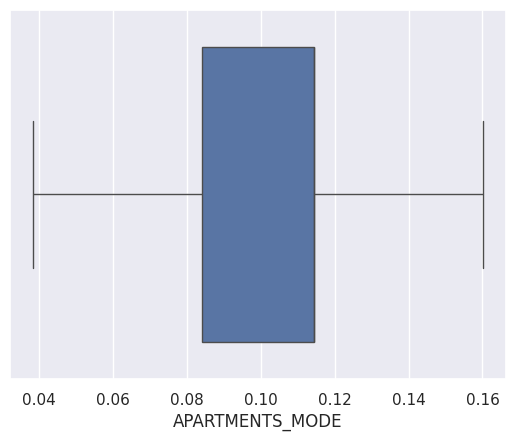

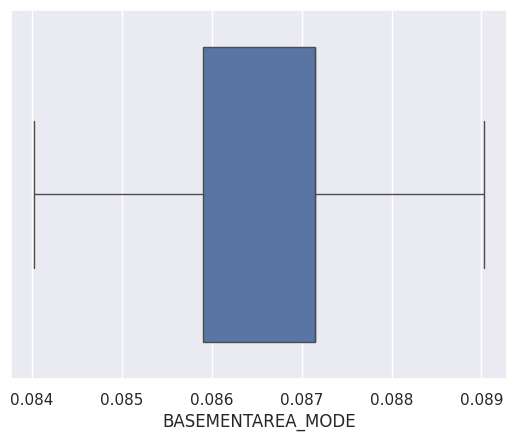

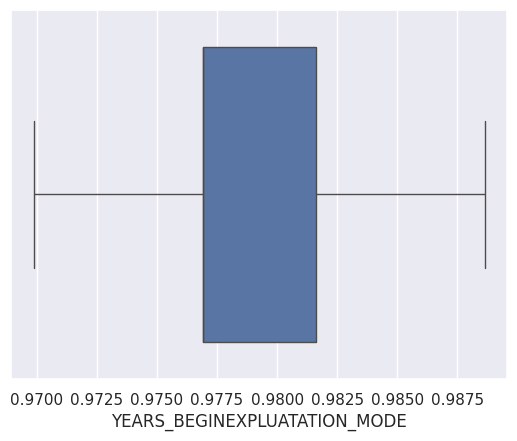

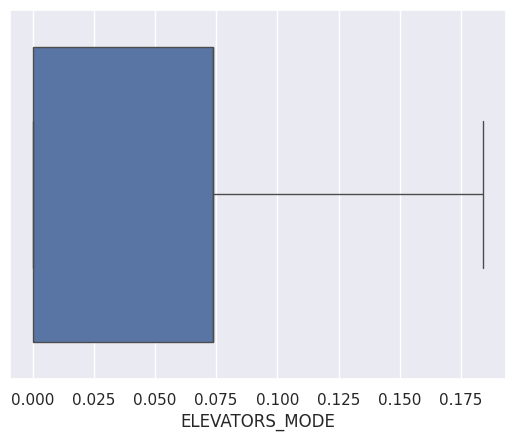

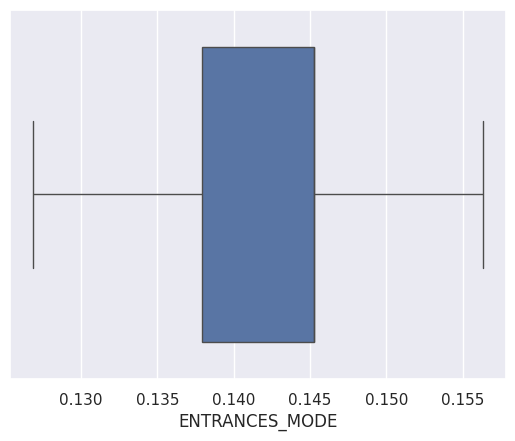

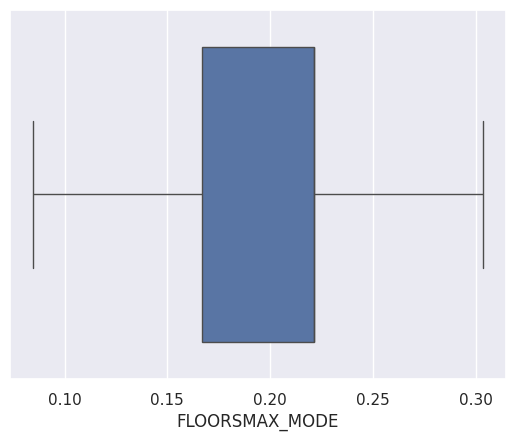

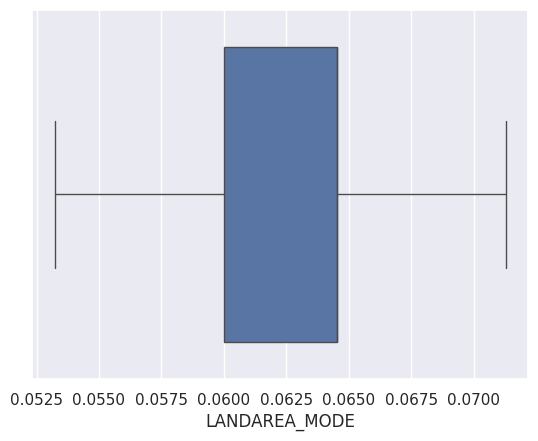

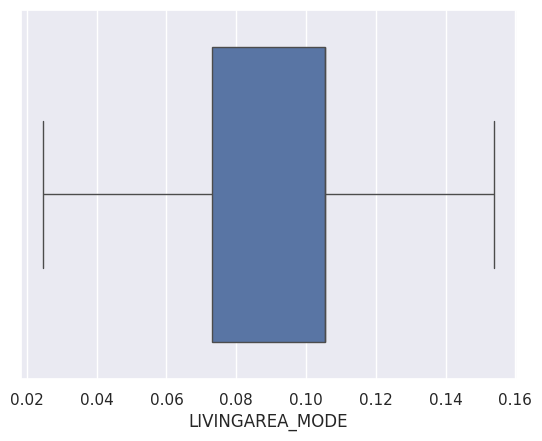

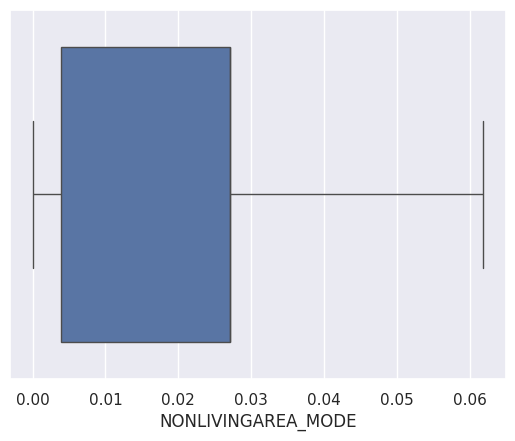

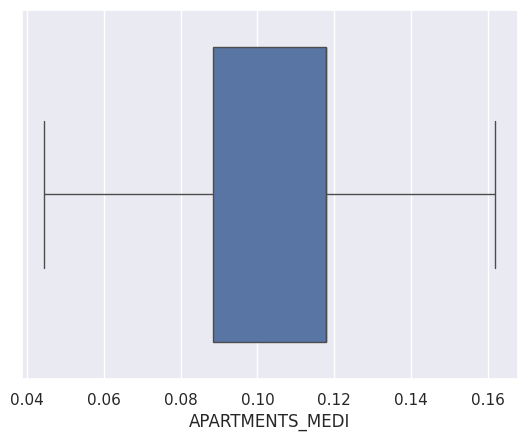

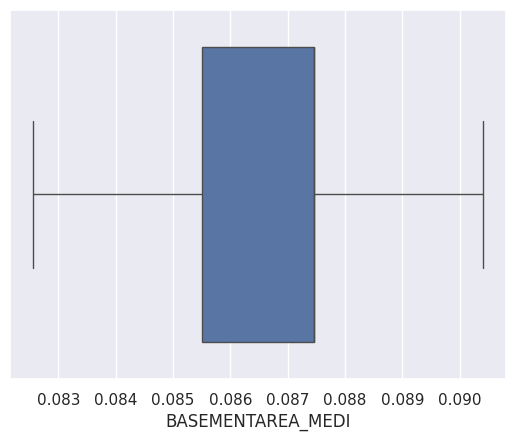

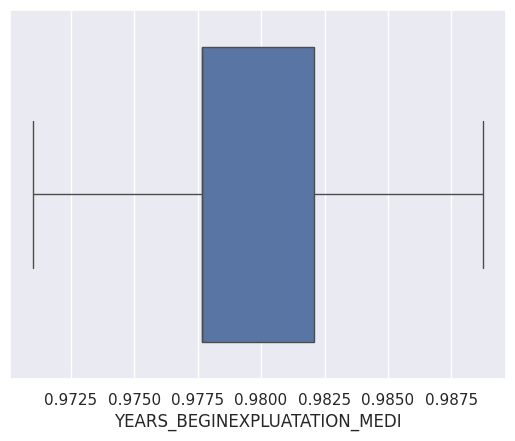

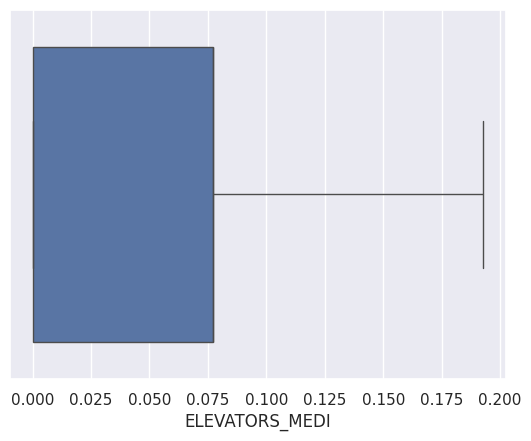

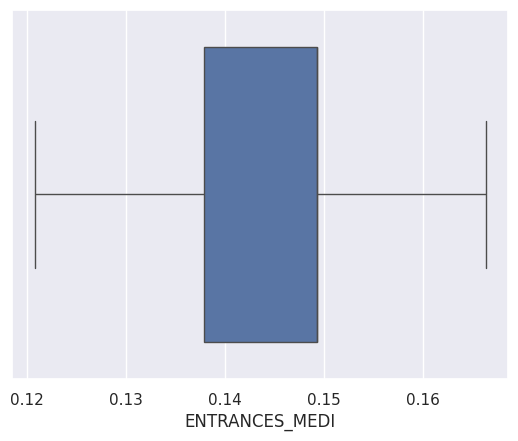

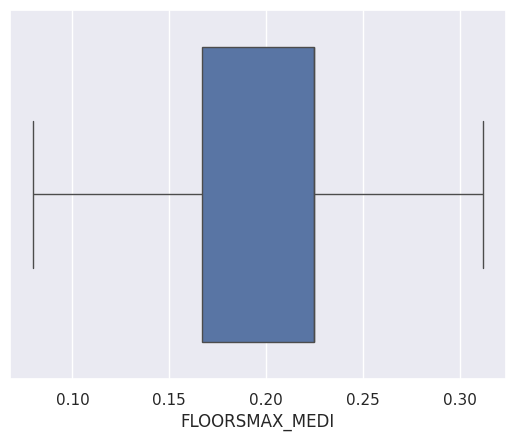

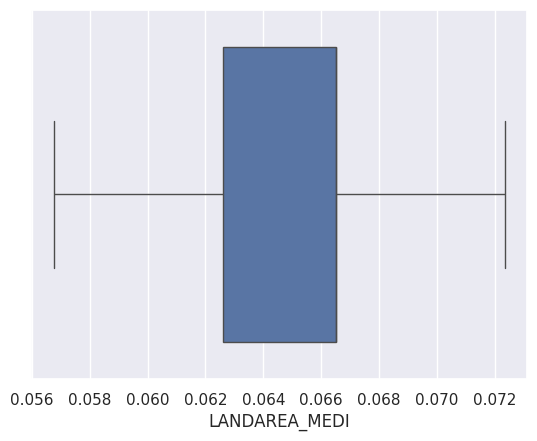

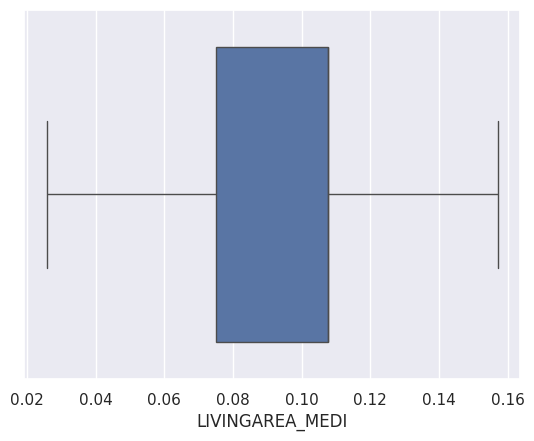

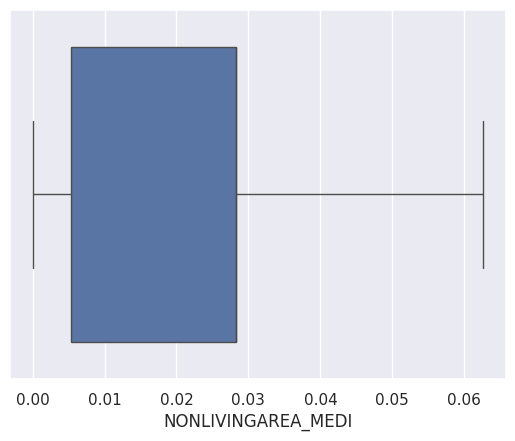

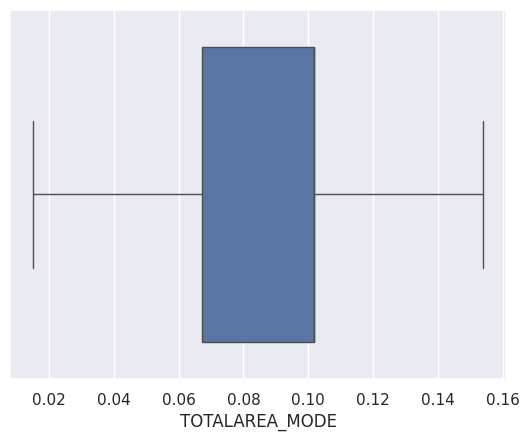

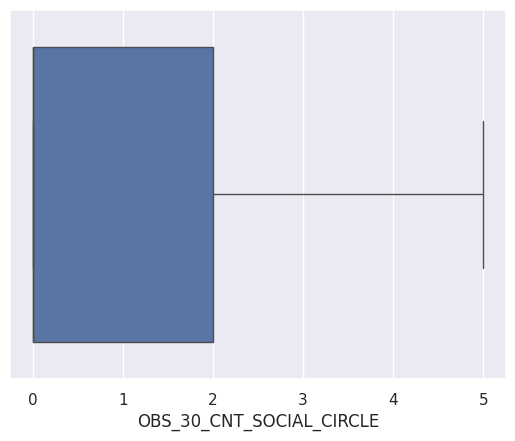

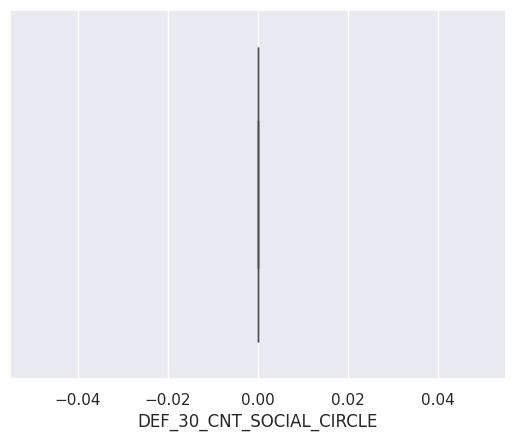

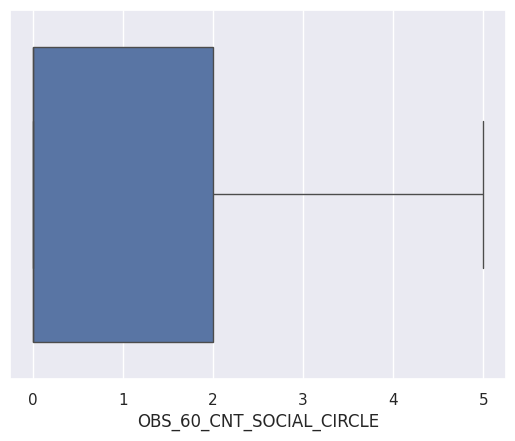

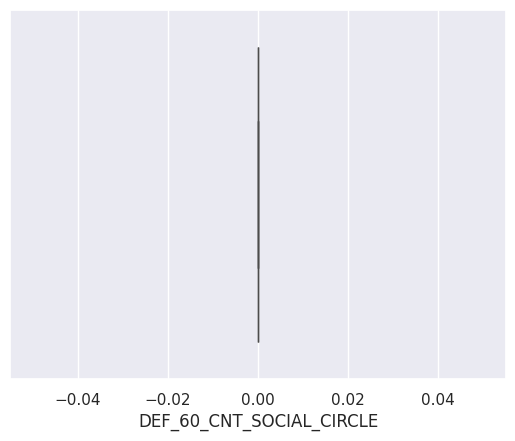

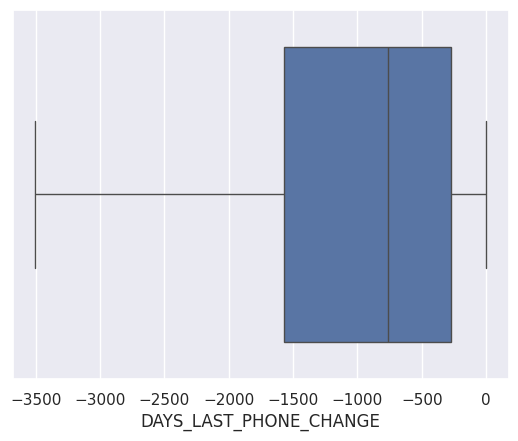

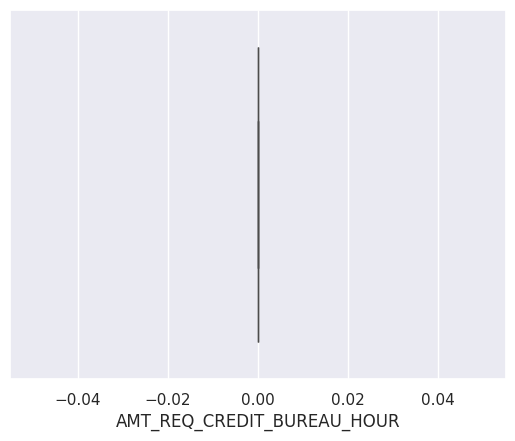

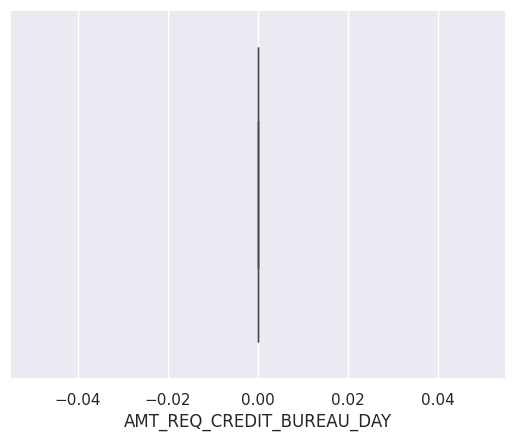

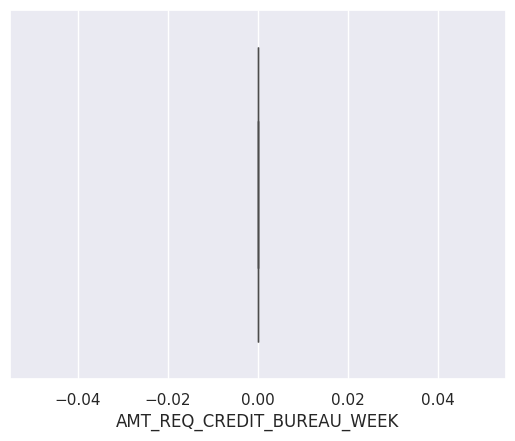

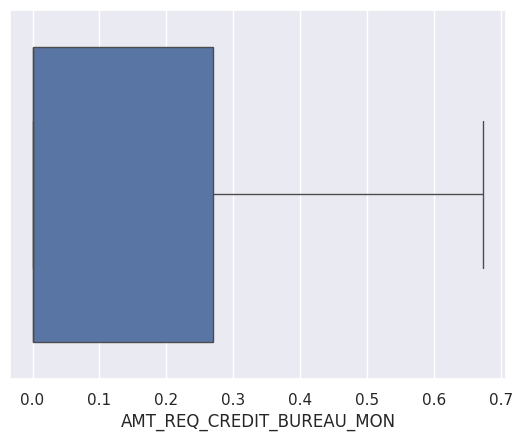

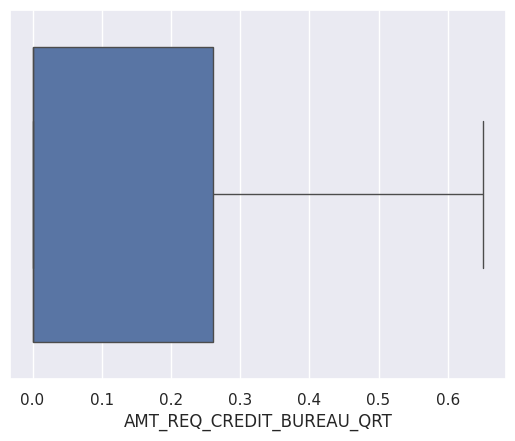

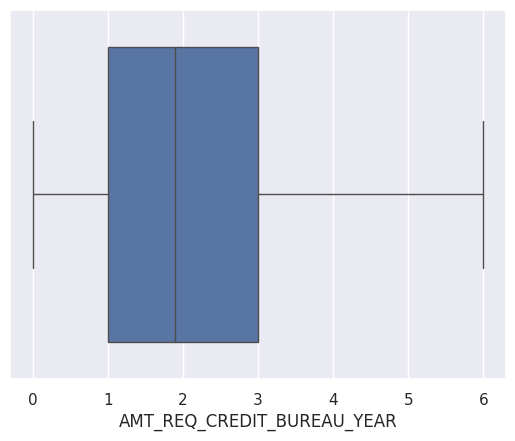

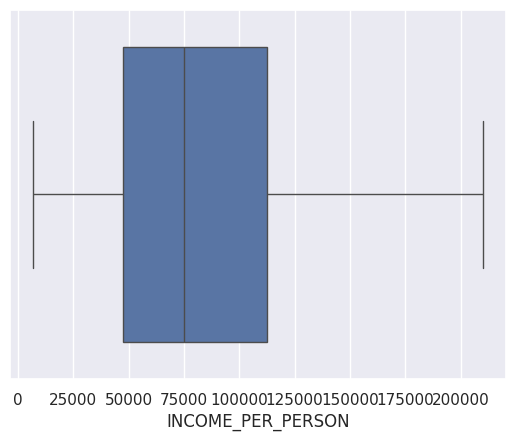

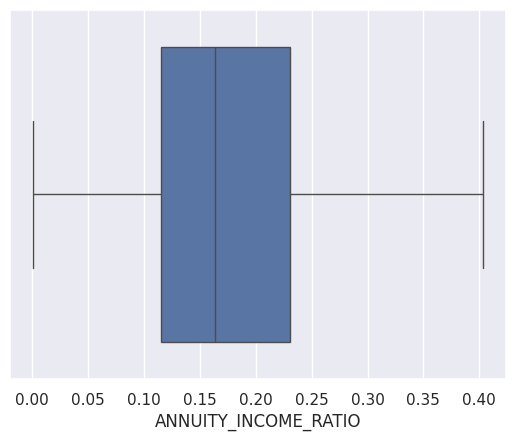

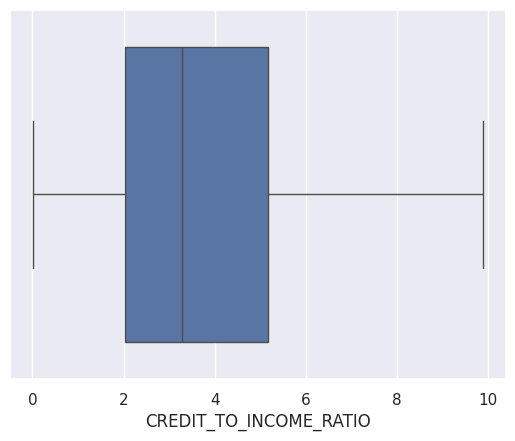

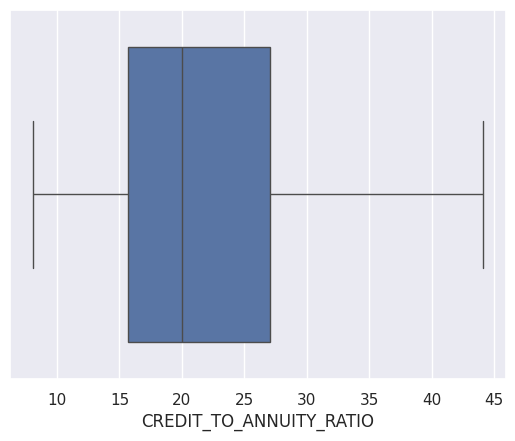

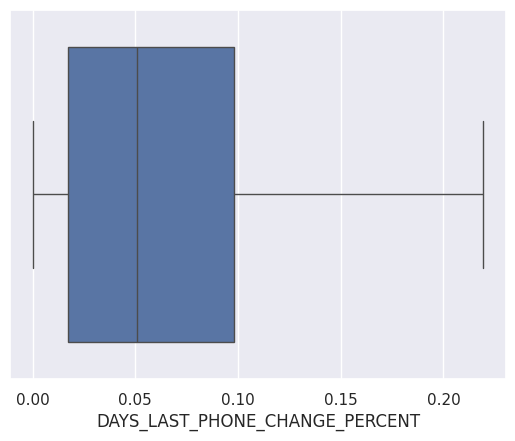

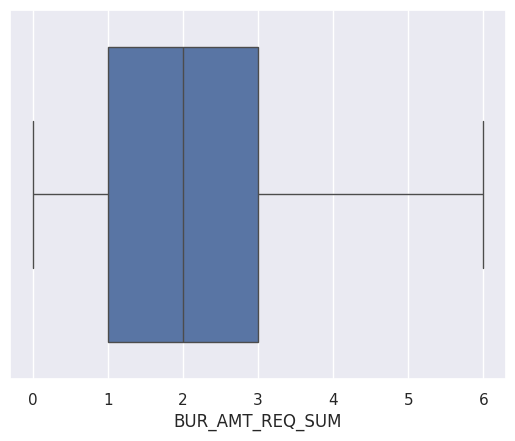

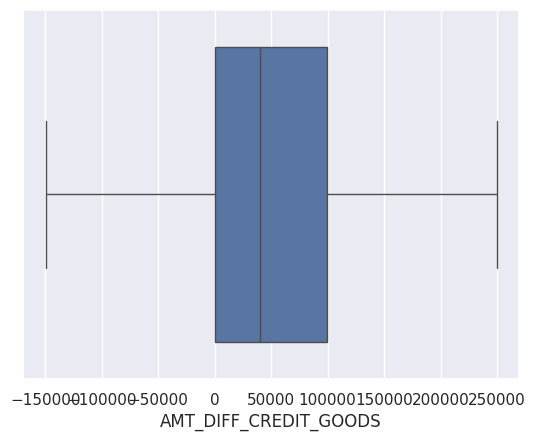

In [12]:
for i in data.columns:
    if data[i].dtype in [int, float] and data[i].nunique() > 2 and i != 'TARGET':
        data[i] = np.where(data[i] > Upper[i], Upper[i], data[i])
        data[i] = np.where(data[i] < Lower[i], Lower[i], data[i])
        sns.boxplot(data=data, x=data[i])
        plt.show()

## Categorical Conversion

In [13]:
for i in data.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  data[i] = le.fit_transform(data[i])

### Scaling and Splitting

In [14]:
targets = data['TARGET']

inputs = data.drop(['TARGET'],axis=1)

In [15]:
scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_TO_INCOME_RATIO,CREDIT_TO_ANNUITY_RATIO,DAYS_LAST_PHONE_CHANGE_PERCENT,BUR_AMT_REQ_SUM,AMT_DIFF_CREDIT_GOODS
0,-0.319984,1.396122,1.401434,-1.495268,2.325412,0.610475,-0.332679,1.956214,-0.323196,0.43642,...,2.275830,-0.585277,-0.533046,-0.707037,0.871434,-0.687385,-1.634120,-1.145118,-0.207710,-0.195505
1,-0.319984,-0.716142,1.401434,0.668776,-0.594383,1.163543,1.827495,1.676589,1.948837,0.43642,...,2.275830,-0.585277,0.709858,2.350833,0.214727,0.548831,0.588167,0.176292,0.934610,0.642008
2,-0.319984,-0.716142,1.401434,-1.495268,-0.594383,0.549023,-0.254496,0.932059,-0.094649,0.43642,...,2.275830,-0.585277,0.709858,0.247192,0.160947,-0.604750,-1.145344,0.316316,0.934610,-0.900868
3,-0.319984,-0.716142,-0.713555,0.668776,-0.594383,1.163543,-0.890437,-0.140461,-0.901288,0.43642,...,-0.554199,-0.585277,-1.154498,2.350833,-0.911905,-1.201901,-1.458477,0.714067,-1.350030,-0.454735
4,-0.319984,1.396122,-0.713555,0.668776,-0.594383,-0.680019,-0.749029,-0.827431,-0.874400,0.43642,...,-0.554199,-0.585277,1.331311,0.464062,-0.444569,-0.480491,-0.278093,-0.992363,0.934610,0.212707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.319984,-0.716142,-0.713555,-1.495268,-0.594383,-1.171636,-0.373586,0.276081,-0.229088,0.43642,...,0.577813,0.494829,0.024224,-0.967282,2.539741,0.845736,-0.873041,0.094319,0.064941,-0.900868
49996,-0.319984,1.396122,-0.713555,-1.495268,-0.594383,-0.987280,-1.088126,-0.941870,-1.035727,0.43642,...,0.577813,0.494829,0.024224,0.030322,-0.230277,-0.792266,-1.159907,0.017523,0.064941,-0.900868
49997,3.125153,1.396122,1.401434,0.668776,-0.594383,2.392585,0.221864,0.526415,0.443111,0.43642,...,-0.554199,-0.585277,0.088406,2.199024,-1.114354,-0.932902,-0.204449,-0.918102,-0.207710,-0.900868
49998,-0.319984,-0.716142,1.401434,0.668776,0.865515,-0.372759,-0.184947,0.365997,-0.229088,0.43642,...,-0.554199,2.114986,2.574215,-0.837159,0.639088,-0.006952,-0.655432,1.680546,2.076930,0.169851


In [16]:
X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42)

# Modelling

In [17]:
def create_model(trial):
    # Building artificial neural network
    model = Sequential()

    # First hidden layer
    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dropout(trial.suggest_float("dropout_ann_1", 0.1, 0.5)))

    # Second hidden layer
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dropout(trial.suggest_float("dropout_ann_2", 0.1, 0.5)))

    # Output layer
    model.add(Dense(units=1, activation='sigmoid'))

    # Suggest hyperparameters for the optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate, clipvalue=1.0)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate, clipvalue=1.0)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate, clipvalue=1.0)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate, clipvalue=1.0)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])

    return model

In [39]:
def optimal(trial):

    # Suggest the number of epochs and batch size
    epochs = trial.suggest_int('epochs', 30, 80)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    model = create_model(trial)

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=epochs, callbacks=[early_stop],
                        batch_size=batch_size, verbose=0)

    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)

    return auc

study = optuna.create_study(direction='maximize', sampler=TPESampler())
study.optimize(optimal, n_trials=2)

'''
I'm aware that n_trials=2 makes patience=5 redundant but I got highest results with n_trials=2.
That's why I sticked with 2 trials without removing early_stop line.
'''

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-05-29 20:05:10,019] A new study created in memory with name: no-name-17594b70-48b3-47f6-88e3-af33ecb865b9
/tmp/ipykernel_7751/327827548.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: AUC,loss
  current = self.get_monitor_value(logs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[I 2026-05-29 20:07:42,261] Trial 0 finished with value: 0.7066707398690264 and parameters: {'epochs': 34, 'batch_size': 21, 'units_layer1': 32, 'dropout_ann_1': 0.4005853735921223, 'units_layer2': 29, 'dropout_ann_2': 0.4292955940902986, 'optimizer': 'rmsprop', 'learning_rate': 7.991016067600963e-05}. Best is trial 0 with value: 0.7066707398690264.
/tmp/ipykernel_7751/327827548.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: AUC,loss
  current = self.get_monitor_value(logs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[I 2026-05-29 20:08:42,631] Trial 1 finished with value: 0.7254425161336572 and parameters: {'epochs': 37, 'batch_size': 62, 'units_layer1': 20, 'dropout_ann_1': 0.2503641517135131, 'units_layer2': 32, 'dropout_ann_2': 0.4300509703091524, 'optimizer': 'adagrad', 'learning_rate': 0.007769118525330941}. Best is trial 1 with value: 0.7254425161336572.


Best trial: 0.7254425161336572
Best hyperparameters: {'epochs': 37, 'batch_size': 62, 'units_layer1': 20, 'dropout_ann_1': 0.2503641517135131, 'units_layer2': 32, 'dropout_ann_2': 0.4300509703091524, 'optimizer': 'adagrad', 'learning_rate': 0.007769118525330941}


In [40]:
best_params = study.best_trial.params

best_params

{'epochs': 37,
 'batch_size': 62,
 'units_layer1': 20,
 'dropout_ann_1': 0.2503641517135131,
 'units_layer2': 32,
 'dropout_ann_2': 0.4300509703091524,
 'optimizer': 'adagrad',
 'learning_rate': 0.007769118525330941}

In [41]:
# Train the final model with the best hyperparameters
best_model = Sequential()

# First hidden layer
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dropout(best_params['dropout_ann_1']))

# Second hidden layer
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dropout(best_params['dropout_ann_2']))

# Output layer
best_model.add(Dense(1, activation='sigmoid'))

In [42]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'], clipvalue=1.0)
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'], clipvalue=1.0)
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'], clipvalue=1.0)
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'], clipvalue=1.0)

In [43]:
best_model.compile(optimizer=best_optimizer, loss='binary_crossentropy', metrics=['AUC'])

In [44]:
def evaluate(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'])

    '''Predictions and probabilities for the training set'''

    y_train_prob = model.predict(X_train)

    '''Predictions and probabilities for the test set'''

    y_test_prob = model.predict(X_test)

    '''Calculate metrics for the training set'''

    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1


    '''Calculate metrics for the test set'''

    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1


    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],

    })

    return results

In [45]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.5708 - loss: 0.3470
Epoch 2/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.6182 - loss: 0.2998
Epoch 3/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6393 - loss: 0.2905
Epoch 4/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6384 - loss: 0.2894
Epoch 5/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.6552 - loss: 0.2826
Epoch 6/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.6647 - loss: 0.2788
Epoch 7/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6678 - loss: 0.2770
Epoch 8/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6783 - loss: 0.2746
Epoch 9/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6786 - loss: 0.2740
Epoch 10/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6804 - loss: 0.2733
Epoch 11/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6874 - loss: 0.2707
Epoch 12/37
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6895 - loss: 0.2702
Epoch 13/37
646/646 ━━━━━

,Dataset,Gini
0,Train,50.991790
1,Test,46.785581
